# **Problem Statement**

## **Business Context**

Aeolus Renewables is an independent power producer operating a fleet of 1,150 onshore wind turbines (2.5 MW class) across 16 wind farms in the central plains region, with a combined installed capacity of roughly 2.87 GW. The company sells the electricity its turbines produce to the grid under long-term power purchase agreements, where revenue is tied directly to how much energy is delivered - so every hour a turbine is offline is energy that cannot be sold. A regional operations centre monitors the fleet around the clock, supported by an O&M organisation of about 140 field technicians.

Each turbine continuously streams condition data through its SCADA (Supervisory Control and Data Acquisition) system - drivetrain vibration, bearing and oil temperatures, rotor and generator speed, and power output - recorded as 10-minute averages, the standard logging resolution for utility-scale turbines. The exact channels vary by turbine type, but together they describe the health of the main subassemblies in near-real time. Today, maintenance runs on a mix of fixed-interval inspections and reactive repair: technicians follow a scheduled service calendar, and the control room responds when an automated alarm trips or a turbine faults offline.

The most consequential components are in the drivetrain - the gearbox and main bearing - which are expensive, slow to procure, and require a mobile crane to replace. The gearbox alone represents approximately 13% of the overall capital cost of an onshore turbine, and within gearboxes the failures are dominated by bearings: one widely-cited breakdown puts the split at bearings (70%), gears (26%) and other causes (4%). The core problem is recognition. By the time a drivetrain fault has developed far enough to matter, its signature is real but still tangled in normal operating noise across many channels - and the existing fixed thresholds only trip once the fault is near-catastrophic, when the turbine is already offline or the component has seized. A genuinely fault drivetrain can run for hours or days looking "normal" to a threshold alarm, while a control-room analyst has no practical way to tell it apart from a healthy machine reacting to gusty wind. The consequences:

- Each unplanned drivetrain failure takes a turbine offline for an estimated 7–21 days, directly forfeiting saleable energy under the power purchase agreement.
- Emergency crane mobilisation and expedited parts run at a steep premium over the same work scheduled in advance, making an unplanned gearbox replacement a major cost event.
- A degrading main bearing left running frequently destroys the gearbox it feeds, converting a contained repair into a far larger one.
- Control-room analysts manually scan a flood of channels across 1,150 turbines, and alarm fatigue means genuine degradation signals slip through unnoticed until the machine faults offline.


## **Objective**

This proof of concept builds a drivetrain-condition classifier that reads each turbine's live sensor signature and labels the drivetrain as "fault" or "normal", serving operations-centre analysts and maintenance planners. The solution

- Reads each turbine's multi-channel sensor signature and produces a clear fault-vs-normal signal, so analysts can concentrate on the handful of machines genuinely in a fault condition rather than scanning the whole fleet.
- Distinguishes a truly fault drivetrain from normal operating noise more reliably than fixed thresholds, catching faults that are present but not yet severe enough to trip a catastrophic alarm - the window in which a turbine can still be stopped before a bearing fault cascades into gearbox destruction.
Is deliberately tuned to favour catching true failures over avoiding false alerts, because a missed fault drivetrain costs far more than an unnecessary inspection.
- Establishes a measurable detection baseline on historical fleet data, so the capability's accuracy and its operational value can be judged on evidence before any wider rollout.

Once proven at proof-of-concept scale, this capability would give Aeolus a defensible basis to move drivetrain maintenance from reactive repair toward condition-based intervention - reducing unplanned downtime, protecting saleable energy revenue, and containing repairs before they escalate across a 1150-turbine fleet.

## **Data Dictionary**

The dataset, `wind_turbine_detection.csv` contains 10-minute SCADA records for 15 turbines.

### Identifiers & Metadata

| Column | Data Type | Description |
| --- | --- | --- |
| timestamp | datetime | Date and time of the 10-minute logging interval; establishes chronological sequence. |
| turbine_id | object (categorical) | Unique code identifying individual wind turbines; used to track specific asset history. |

### Environmental Conditions

| Column | Data Type | Description |
| --- | --- | --- |
| rated_power_kW | float | Maximum engineered power capacity of the turbine; defines its performance baseline. |
| wind_speed_mps | float | Velocity of the incoming wind; the primary driver of kinetic energy input. |
| wind_direction_deg | float | Compass direction of oncoming wind; used to assess turbine alignment. |
| turbulence_intensity | float | Measure of wind speed fluctuation; higher intensity increases structural fatigue. |
| air_density_kgm3 | float | Mass of air per unit volume; directly impacts aerodynamic lift and power potential. |
| ambient_temp_C | float | Outdoor air temperature surrounding the turbine; affects cooling efficiency. |
| humidity_pct | float | Relative moisture level in the air; flags risks for electrical insulation degradation or corrosion. |

### Operational Control & State

| Column | Data Type | Description |
| --- | --- | --- |
| power_output_kW | float | Real-time electricity generated; drops or fluctuations can signal mechanical drag. |
| rotor_speed_rpm | float | Rotational speed of the main blades; reflects low-speed shaft dynamics. |
| generator_speed_rpm | float | Rotational speed of the generator shaft; crucial for detecting gearbox slip. |
| blade_pitch_angle_deg | float | Angle of the blades relative to the wind; adjusted to control power and rotor speed. |
| yaw_misalignment_deg | float | Angle deviation between wind direction and nacelle orientation; high values cause uneven drivetrain stress. |

### Thermal Metrics (Component Health)

| Column | Data Type | Description |
| --- | --- | --- |
| gearbox_oil_temp_C | float | Temperature of the lubricating oil; spikes indicate excessive mechanical friction. |
| gearbox_bearing_temp_C | float | Internal temperature of gearbox bearings; a leading indicator of bearing wear. |
| generator_bearing_temp_C | float | Temperature of generator bearings; flags alignment or lubrication issues. |
| generator_winding_temp_C | float | Temperature of internal electrical coils; spikes indicate electrical overload or cooling failure. |
| main_bearing_temp_C | float | Temperature of the primary low-speed shaft bearing; handles massive structural loads. |
| nacelle_temp_C | float | Air temperature inside the enclosed housing; reflects global internal heat dissipation. |

### Vibration & Diagnostics (FFT)

| Column | Data Type | Description |
| --- | --- | --- |
| drivetrain_vibration_rms_mmps | float | Overall energy of drivetrain vibrations; general indicator of mechanical roughness. |
| tower_vibration_mmps | float | Structural oscillation of the turbine tower; flags aerodynamic or rotor imbalance. |
| vib_fft_bearing_bpfo | float | Vibration amplitude at the bearing outer-race defect frequency; tracks outer-ring pitting. |
| vib_fft_bearing_bpfi | float | Vibration amplitude at the bearing inner-race defect frequency; tracks inner-ring pitting. |
| vib_fft_gearmesh | float | Vibration amplitude at the teeth-meshing frequency; isolates gearbox tooth wear or misalignment. |
| vib_fft_sideband | float | Vibration amplitude surrounding main frequencies; flags localized faults like cracked gear teeth. |

### Lubrication & Particle Analysis

| Column | Data Type | Description |
| --- | --- | --- |
| oil_particle_count | float | Quantity of metallic debris suspended in lubricating oil; direct indicator of component wear. |
| oil_pressure_bar | float | Pressure of the lubrication system; drops indicate leaks, pump failures, or oil thinning. |

### Asset Lifecycle & History

| Column | Data Type | Description |
| --- | --- | --- |
| operating_hours_total | float | Cumulative runtime of the turbine; represents the asset's total mechanical mileage. |
| cumulative_energy_MWh | float | Total historical electricity produced; measures the lifetime work done by the drivetrain. |
| load_cycles | int | Total count of fatigue-inducing stress variations; correlates directly with structural aging. |
| hours_since_last_maintenance | float | Time elapsed since last service; crucial for identifying maintenance-cycle fatigue. |
| prior_fault_count | int | Total historical fault events triggered; highlights chronic or poorly repaired issues. |
| component_age_days | float | Elapsed lifetime of active components; captures chronological wear independent of runtime. |

### Targets (Labels)

| Column | Data Type | Description |
| --- | --- | --- |
| failure | int (0/1) | The target variable; boolean flag indicating if the drivetrain or turbine is healthy (0) or failing (1). |

# **Installing and Importing the Necessary Libraries**

| Library | Version |
| --- | --- |
| numpy | 2.5.2 |
| pandas | 2.3.3 |
| matplotlib | 3.11.1 |
| seaborn | 0.13.2 |
| scikit-learn | 1.9.0 |
| xgboost | 3.4.1 |
| statsmodels | 0.15.0 |
| scipy | 1.18.1 |
| jupyter | 1.1.1 |
| ipykernel | 6.31.0 |
| tensorflow | 2.21.0 |
| joblib | 1.6.0 |

```bash
python -m pip install numpy==2.5.2 pandas==2.3.3 matplotlib==3.11.1 seaborn==0.13.2 scikit-learn==1.9.0 xgboost==3.4.1 statsmodels==0.15.0 scipy==1.18.1 jupyter==1.1.1 ipykernel==6.31.0 tensorflow==2.21.0 joblib==1.6.0
```

In [2]:
from pathlib import Path
import os, sys, time, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, fbeta_score, average_precision_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
root = Path.cwd()
if not (root / 'data/raw').exists(): root = root.parent
sys.path.insert(0, str(root))
from src.modeling.artifacts import BalancedXGBClassifier
from src.modeling.neural_networks import dataset
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
output = root / 'models/template_aligned'
output.mkdir(parents=True, exist_ok=True)
def observation(text): display(Markdown('**Observation:** ' + text))


# **Loading the Data**

In [3]:
# uncomment and run the below code snippets if you're using Google Colab and the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
data = pd.read_csv(root / 'data/raw/wind_turbine_detection.csv')
print('Loaded', len(data), 'SCADA records.')

Loaded 131760 SCADA records.


# **Data Overview**

## Viewing the first and last 5 rows of the dataset

In [5]:
display(data.head(5)); display(data.tail(5))

,timestamp,turbine_id,rated_power_kW,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,yaw_misalignment_deg,gearbox_oil_temp_C,gearbox_bearing_temp_C,generator_bearing_temp_C,generator_winding_temp_C,main_bearing_temp_C,nacelle_temp_C,drivetrain_vibration_rms_mmps,tower_vibration_mmps,vib_fft_bearing_bpfo,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,prior_fault_count,component_age_days,failure
0,1/1/2024 0:00,T001,1500,2.335,151.993,0.149,1.205,21.820,68.717,0.000,0.000,14.414,87.761,-5.455,53.728,56.728,57.637,61.546,48.728,29.820,1.518,0.974,0.455,0.391,0.455,0.399,55.756,6.032,19319.612,9587.146,0.000,769.284,0,1360.703,0
1,1/1/2024 0:10,T001,1500,9.166,152.957,0.153,1.200,22.893,74.002,486.762,12.554,1134.433,-0.159,0.489,64.105,67.798,66.841,85.072,58.544,33.649,1.480,0.992,0.455,0.391,0.455,0.399,55.756,5.776,19319.778,9587.227,1.528,769.450,0,1360.710,0
2,1/1/2024 0:20,T001,1500,9.034,158.402,0.201,1.219,22.899,59.616,454.109,12.579,1143.435,1.061,4.220,63.868,66.635,66.093,82.383,58.365,32.667,1.753,1.074,0.455,0.391,0.455,0.399,55.756,5.994,19319.945,9587.302,3.539,769.617,0,1360.717,0
3,1/1/2024 0:30,T001,1500,13.284,159.023,0.159,1.181,22.727,64.676,1446.811,16.941,1526.358,5.718,1.584,83.654,89.761,85.749,128.484,77.257,36.349,1.924,1.379,0.455,0.391,0.455,0.399,55.756,5.541,19320.112,9587.544,5.126,769.784,0,1360.724,0
4,1/1/2024 0:40,T001,1500,2.239,159.842,0.189,1.173,23.742,65.423,0.000,0.194,27.405,88.452,3.400,54.573,57.150,56.817,60.963,51.506,32.234,1.497,0.936,0.455,0.391,0.455,0.399,55.756,6.018,19320.112,9587.544,5.126,769.950,0,1360.731,0


,timestamp,turbine_id,rated_power_kW,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,yaw_misalignment_deg,gearbox_oil_temp_C,gearbox_bearing_temp_C,generator_bearing_temp_C,generator_winding_temp_C,main_bearing_temp_C,nacelle_temp_C,drivetrain_vibration_rms_mmps,tower_vibration_mmps,vib_fft_bearing_bpfo,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,prior_fault_count,component_age_days,failure
131755,3/1/2024 23:10,T015,3000,5.680,108.327,0.306,1.200,19.599,60.093,95.437,8.399,764.196,-0.123,-6.325,53.286,60.399,56.996,63.265,50.056,27.808,2.139,0.886,0.322,0.333,0.424,0.224,78.731,5.741,36147.152,33527.459,13588.408,2588.506,63,784.507,0
131756,3/1/2024 23:20,T015,3000,6.945,111.198,0.151,1.207,18.800,63.952,254.325,9.789,886.754,0.507,1.873,54.811,62.961,60.368,67.812,50.091,27.891,1.470,0.956,0.322,0.333,0.424,0.224,78.731,6.125,36147.318,33527.501,13589.919,2588.673,63,784.514,0
131757,3/1/2024 23:30,T015,3000,2.191,113.020,0.148,1.214,18.331,61.764,0.000,0.029,3.975,87.072,0.880,51.704,60.440,57.181,63.706,47.760,26.242,1.793,0.897,0.322,0.333,0.424,0.224,78.731,5.955,36147.318,33527.501,13589.919,2588.839,63,784.521,0
131758,3/1/2024 23:40,T015,3000,11.003,117.356,0.178,1.200,19.640,62.729,2056.378,14.527,1297.923,0.869,4.662,72.463,84.704,78.389,111.169,66.612,31.989,1.764,1.212,0.322,0.333,0.424,0.224,78.731,5.920,36147.485,33527.844,13591.700,2589.006,63,784.528,0
131759,3/1/2024 23:50,T015,3000,2.231,116.146,0.160,1.206,19.598,66.575,0.000,0.040,0.936,88.206,0.105,51.646,60.774,57.721,63.360,46.512,28.247,1.833,1.239,0.322,0.333,0.424,0.224,78.731,5.886,36147.485,33527.844,13591.700,2589.173,63,784.535,0


**Observations:** Both ends of the source data are displayed to inspect its structure; these are records, not independent turbines or failure episodes.

## Checking the shape of the dataset

In [6]:
print('Rows and columns:', data.shape)

Rows and columns: (131760, 35)


## Checking the attribute types

In [7]:
display(data.dtypes.rename('data_type').to_frame())

,data_type
timestamp,object
turbine_id,object
rated_power_kW,int64
wind_speed_mps,float64
wind_direction_deg,float64
turbulence_intensity,float64
air_density_kgm3,float64
ambient_temp_C,float64
humidity_pct,float64
power_output_kW,float64


**Observations:** Timestamp is initially read as text and converted below; turbine ID is categorical, failure is a binary target, and the remaining source fields are numeric.

## Checking the statistical summary

In [8]:
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
rated_power_kW,131760.0,2166.666667,743.567808,1500.000,1500.00000,2000.0000,3000.00000,3600.000
wind_speed_mps,131760.0,7.649297,4.066898,0.015,4.62700,7.1365,10.08800,32.000
wind_direction_deg,131760.0,163.155270,106.644769,0.000,68.28875,150.5440,254.89200,359.995
turbulence_intensity,131760.0,0.175353,0.033725,0.121,0.15100,0.1680,0.19100,0.450
air_density_kgm3,131760.0,1.244980,0.037329,1.140,1.21400,1.2450,1.27600,1.345
ambient_temp_C,131760.0,10.011035,8.999438,-9.748,2.17800,9.9770,17.85900,29.078
humidity_pct,131760.0,60.023310,13.067340,18.908,50.03800,59.9980,70.00800,99.693
power_output_kW,131760.0,633.607766,869.596264,0.000,17.35800,198.5185,1014.10925,3672.000
rotor_speed_rpm,131760.0,9.981842,4.856042,0.000,7.30700,10.1970,13.59600,17.628
generator_speed_rpm,131760.0,898.629973,436.640301,0.000,657.56950,917.7410,1223.73300,1590.833


**Observations:** Compare the quartiles and maxima to identify heavy tails. Extreme condition readings may represent faults and are retained rather than automatically removed.

## Checking for missing values

In [9]:
display(pd.DataFrame({'missing_count': data.isna().sum(), 'missing_pct': data.isna().mean()*100}))

,missing_count,missing_pct
timestamp,0,0.000000
turbine_id,0,0.000000
rated_power_kW,0,0.000000
wind_speed_mps,0,0.000000
wind_direction_deg,0,0.000000
turbulence_intensity,0,0.000000
air_density_kgm3,0,0.000000
ambient_temp_C,0,0.000000
humidity_pct,0,0.000000
power_output_kW,0,0.000000


**Observations:** Missingness is small and limited to three sensors. Partition-specific percentages and training-only imputation appear under Missing Value Treatment.

## Checking for duplicate values

In [10]:
print('Duplicate rows:', data.duplicated().sum()); print('Duplicate turbine/timestamp keys:', data.duplicated(['turbine_id','timestamp']).sum())

Duplicate rows: 0
Duplicate turbine/timestamp keys: 0


**Observations:** The source has no duplicate rows or duplicate turbine–timestamp keys; no duplicate removal is needed.

# **Data Preprocessing**

In [11]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['dayofweek'] = data.timestamp.dt.dayofweek
data['hour'] = data.timestamp.dt.hour

# **Exploratory Data Analysis**

## Utility Functions

In [12]:
def histogram(data_df, col, **kwargs):
    fig, ax = plt.subplots(figsize=(9, 3.6))
    sns.histplot(data=data_df, x=col, bins=50, ax=ax)
    ax.set_title(kwargs.get('title', col)); plt.tight_layout(); plt.show()
    s = data_df[col].dropna()
    observation(f"{col}: middle 50% spans {s.quantile(.25):.3f}–{s.quantile(.75):.3f}; range {s.min():.3f}–{s.max():.3f}; skewness {s.skew():.3f}. Extreme values warrant domain review.")
def barchart(data_df, x_col, **kwargs):
    sns.countplot(data=data_df, x=x_col); plt.title(kwargs.get('title', x_col)); plt.show()
    display(data_df[x_col].value_counts().rename('records').to_frame())
def boxplot(data_df, x_col, y_col):
    sns.boxplot(data=data_df, x=x_col, y=y_col, showfliers=True); plt.show()
    summary = data_df.groupby(x_col)[y_col].agg(['median','mean','std','min','max'])
    display(summary)
    observation(f"{y_col}: normal median {summary.loc[0,'median']:.3f}, fault median {summary.loc[1,'median']:.3f}; standard deviations {summary.loc[0,'std']:.3f} and {summary.loc[1,'std']:.3f}. Overlap and outliers mean this is not a standalone fault threshold.")
def scatterplot(data_df, x_col, y_col):
    sns.scatterplot(data=data_df, x=x_col, y=y_col, s=4, alpha=.15)
    plt.show()
    observation(f"Pearson correlation is {data_df[[x_col,y_col]].corr().iloc[0,1]:.4f}. The scatter shows operating regimes and dispersion; correlation alone does not establish causality or identify invalid readings.")


## Univariate Analysis

### `failure`

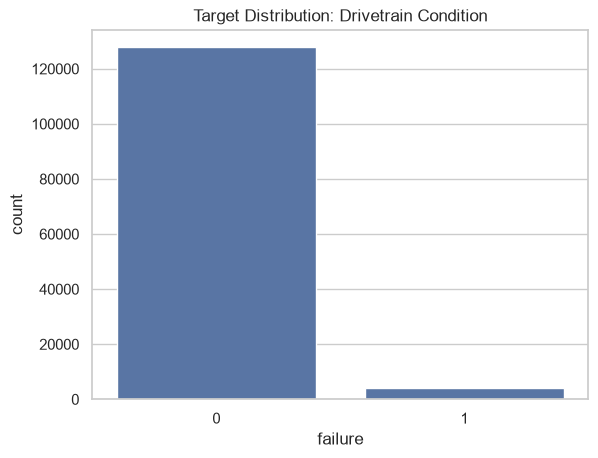

,records
failure,
0,127807
1,3953


In [13]:
barchart(data, 'failure', title='Target Distribution: Drivetrain Condition', xlabel='failure (0 = normal, 1 = fault)')

**Observations:** The positive class is rare (about 3% of records). Accuracy alone would conceal missed failures, so recall and precision–recall performance guide model assessment.

### ```wind_speed_mps```

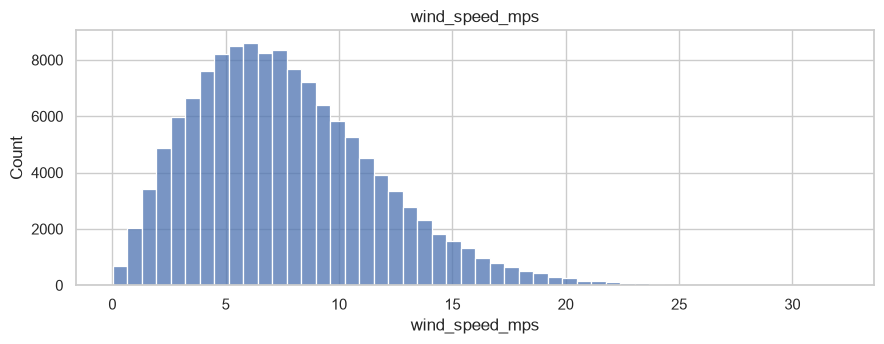

**Observation:** wind_speed_mps: middle 50% spans 4.627–10.088; range 0.015–32.000; skewness 0.778. Extreme values warrant domain review.

In [14]:
histogram(data, 'wind_speed_mps')

**Observation:** wind_speed_mps: middle 50% spans 4.627–10.088; range 0.015–32.000; skewness 0.778. Extreme values warrant domain review.

### ```air_density_kgm3```

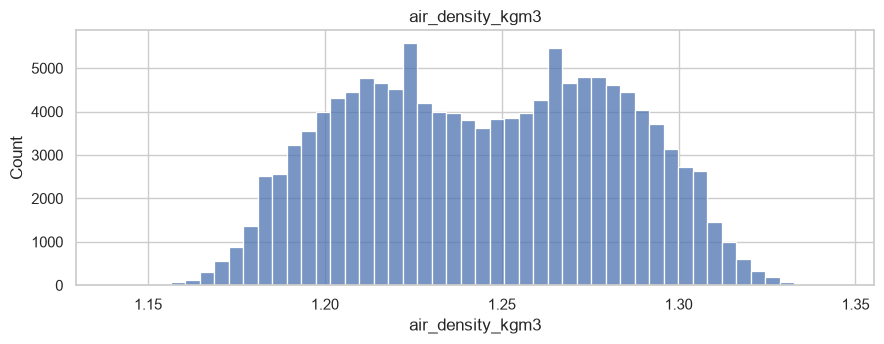

**Observation:** air_density_kgm3: middle 50% spans 1.214–1.276; range 1.140–1.345; skewness -0.005. Extreme values warrant domain review.

In [15]:
histogram(data, 'air_density_kgm3')

**Observation:** air_density_kgm3: middle 50% spans 1.214–1.276; range 1.140–1.345; skewness -0.005. Extreme values warrant domain review.

### ```gearbox_oil_temp_C```

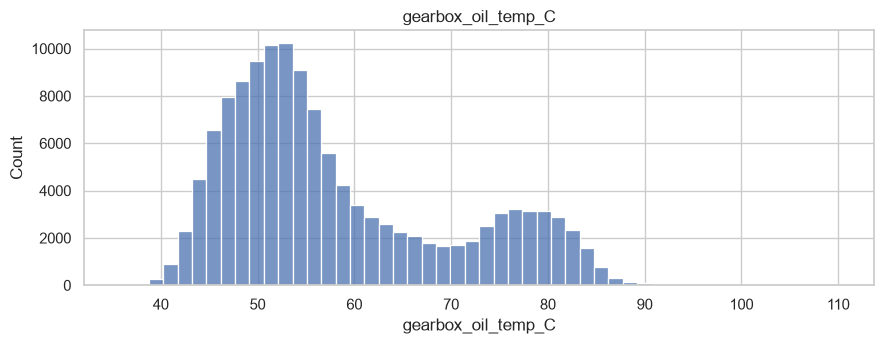

**Observation:** gearbox_oil_temp_C: middle 50% spans 49.427–65.364; range 35.814–109.988; skewness 0.851. Extreme values warrant domain review.

In [16]:
histogram(data, 'gearbox_oil_temp_C')

**Observation:** gearbox_oil_temp_C: middle 50% spans 49.427–65.364; range 35.814–109.988; skewness 0.851. Extreme values warrant domain review.

### ```generator_winding_temp_C```

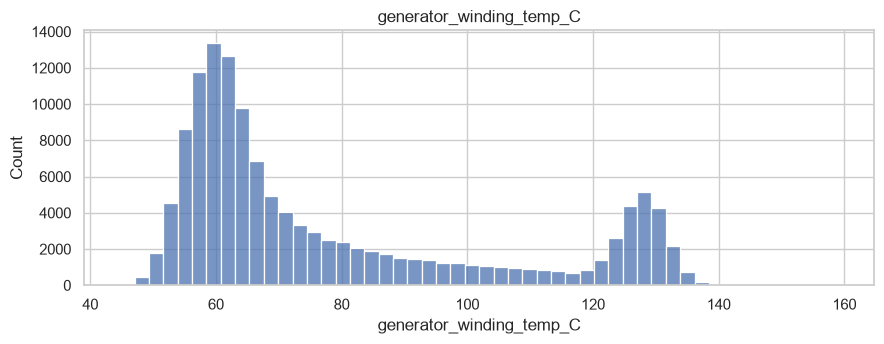

**Observation:** generator_winding_temp_C: middle 50% spans 59.489–92.931; range 44.771–158.996; skewness 1.011. Extreme values warrant domain review.

In [17]:
histogram(data, 'generator_winding_temp_C')

**Observation:** generator_winding_temp_C: middle 50% spans 59.489–92.931; range 44.771–158.996; skewness 1.011. Extreme values warrant domain review.

### ```drivetrain_vibration_rms_mmps```

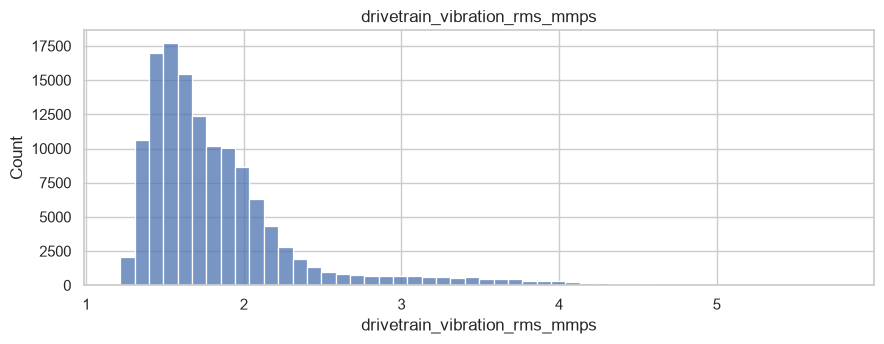

**Observation:** drivetrain_vibration_rms_mmps: middle 50% spans 1.506–1.976; range 1.216–5.770; skewness 2.280. Extreme values warrant domain review.

In [18]:
histogram(data, 'drivetrain_vibration_rms_mmps')

**Observation:** drivetrain_vibration_rms_mmps: middle 50% spans 1.506–1.976; range 1.216–5.770; skewness 2.280. Extreme values warrant domain review.

### ```tower_vibration_mmps```

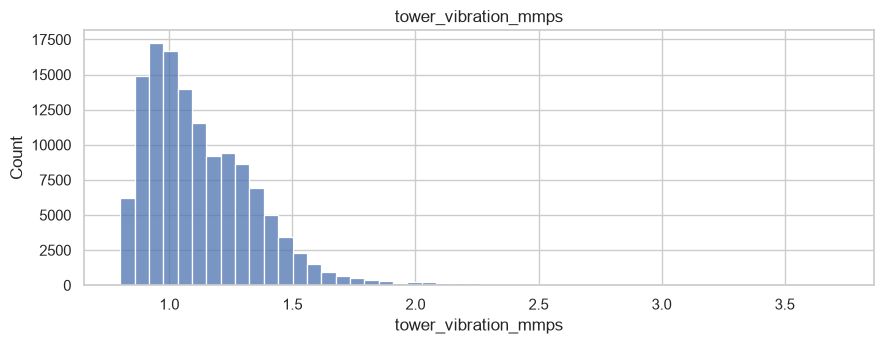

**Observation:** tower_vibration_mmps: middle 50% spans 0.957–1.265; range 0.801–3.717; skewness 1.821. Extreme values warrant domain review.

In [19]:
histogram(data, 'tower_vibration_mmps')

**Observation:** tower_vibration_mmps: middle 50% spans 0.957–1.265; range 0.801–3.717; skewness 1.821. Extreme values warrant domain review.

### ```oil_particle_count```

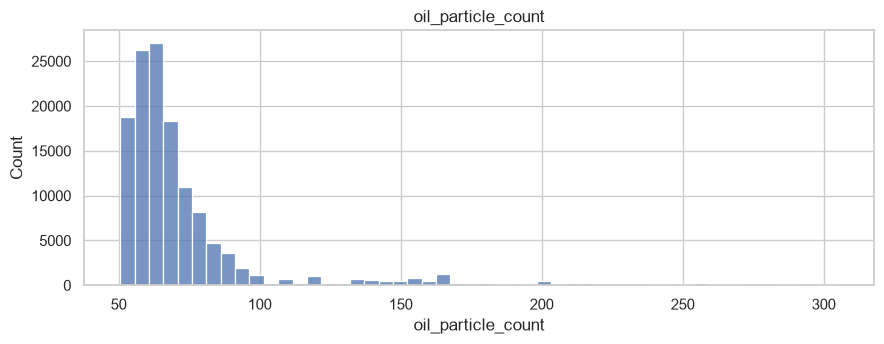

**Observation:** oil_particle_count: middle 50% spans 58.554–74.938; range 50.565–305.105; skewness 3.597. Extreme values warrant domain review.

In [20]:
histogram(data, 'oil_particle_count')

**Observation:** oil_particle_count: middle 50% spans 58.554–74.938; range 50.565–305.105; skewness 3.597. Extreme values warrant domain review.

### ```prior_fault_count```

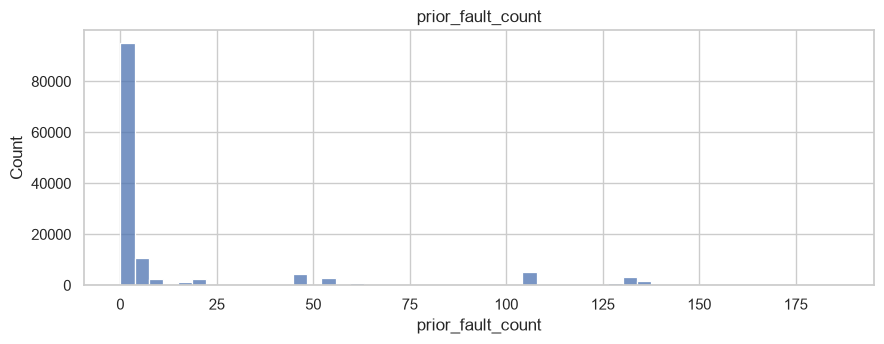

**Observation:** prior_fault_count: middle 50% spans 0.000–4.000; range 0.000–186.000; skewness 2.521. Extreme values warrant domain review.

In [21]:
histogram(data, 'prior_fault_count')

**Observation:** prior_fault_count: middle 50% spans 0.000–4.000; range 0.000–186.000; skewness 2.521. Extreme values warrant domain review.

### ```component_age_days```

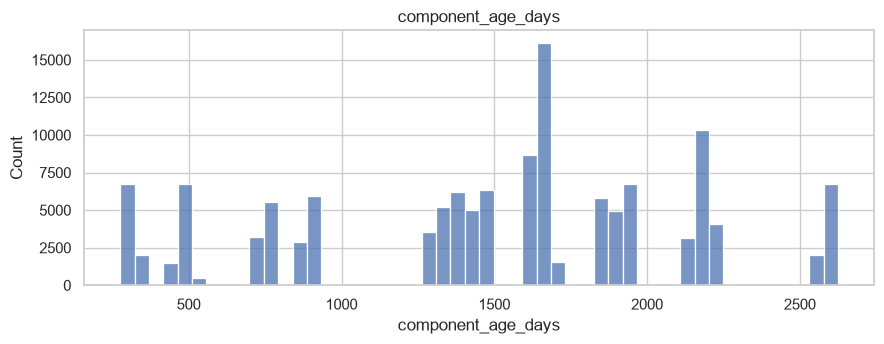

**Observation:** component_age_days: middle 50% spans 912.710–1921.924; range 276.015–2625.264; skewness -0.290. Extreme values warrant domain review.

In [22]:
histogram(data, 'component_age_days')

**Observation:** component_age_days: middle 50% spans 912.710–1921.924; range 276.015–2625.264; skewness -0.290. Extreme values warrant domain review.

## Bivariate Analysis

### ```turbine_id``` vs ```failure```

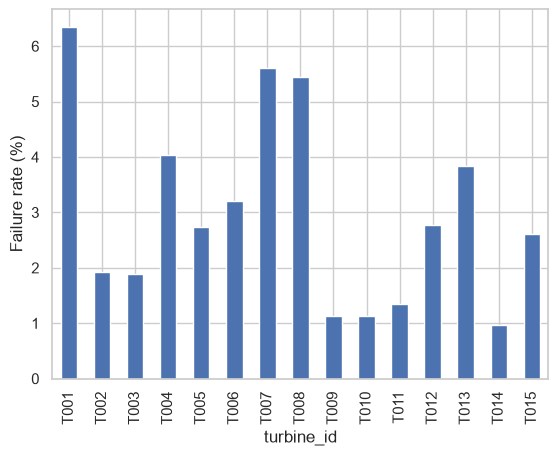

**Observation:** Turbine failure rates range from 0.968% (T014) to 6.352% (T001).

In [23]:
rates = data.groupby('turbine_id').failure.mean().mul(100)
rates.plot.bar(ylabel='Failure rate (%)'); plt.show()
observation(f'Turbine failure rates range from {rates.min():.3f}% ({rates.idxmin()}) to {rates.max():.3f}% ({rates.idxmax()}).')

**Observation:** Turbine failure rates range from 0.968% (T014) to 6.352% (T001).

### `wind_speed_mps` vs `power_output_kW`

,mean,count
wind_speed_mps,,
"(-0.001, 2.0]",0.000000,6577
"(2.0, 4.0]",5.122656,18698
"(4.0, 6.0]",33.232892,25775
"(6.0, 8.0]",203.126547,25847
"(8.0, 10.0]",648.778597,21149
"(10.0, 12.0]",1521.319781,14915
"(12.0, 14.0]",2178.718520,9109
"(14.0, 16.0]",2177.522275,4957
"(16.0, 18.0]",2202.348463,2518


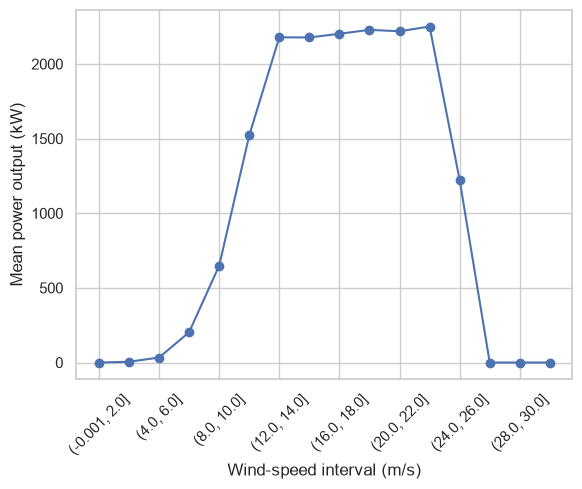

In [24]:
wind_bins = pd.cut(data.wind_speed_mps, bins=np.arange(0, data.wind_speed_mps.max()+2, 2), include_lowest=True)
power_curve = data.groupby(wind_bins, observed=True).power_output_kW.agg(['mean','count'])
display(power_curve)
power_curve['mean'].plot(marker='o', ylabel='Mean power output (kW)', xlabel='Wind-speed interval (m/s)'); plt.xticks(rotation=45); plt.show()

**Observations:** Power generally rises from low-wind operation toward higher output; bin counts expose sparsely supported extremes. Pooling different rated-power classes broadens the relationship, so this is not a manufacturer power curve.

### ```rotor_speed_rpm``` vs ```generator_speed_rpm```

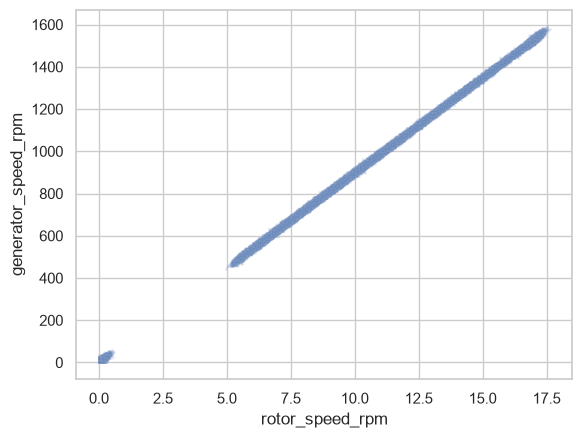

**Observation:** Pearson correlation is 0.9998. The scatter shows operating regimes and dispersion; correlation alone does not establish causality or identify invalid readings.

In [25]:
scatterplot(data, 'rotor_speed_rpm', 'generator_speed_rpm')

**Observation:** Pearson correlation is 0.9998. The scatter shows operating regimes and dispersion; correlation alone does not establish causality or identify invalid readings.

**Observations:** The near-linear rotor/generator relationship indicates strong redundancy. Dispersion around the line is visible, but points should not be labeled faults solely from this plot.

### ```wind_speed_mps``` vs ```rotor_speed_rpm```

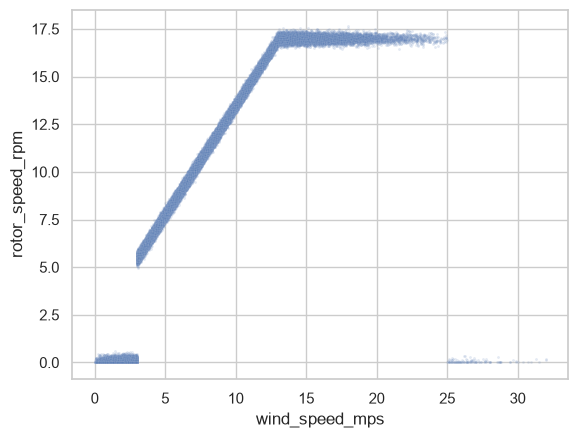

**Observation:** Pearson correlation is 0.9113. The scatter shows operating regimes and dispersion; correlation alone does not establish causality or identify invalid readings.

In [26]:
scatterplot(data, 'wind_speed_mps', 'rotor_speed_rpm')

**Observation:** Pearson correlation is 0.9113. The scatter shows operating regimes and dispersion; correlation alone does not establish causality or identify invalid readings.

**Observations:** Rotor speed follows wind at low operating speeds and is constrained by turbine controls at higher wind. Nonlinear behavior and dispersion are expected across turbine types.

### `drivetrain_vibration_rms_mmps` vs `failure`

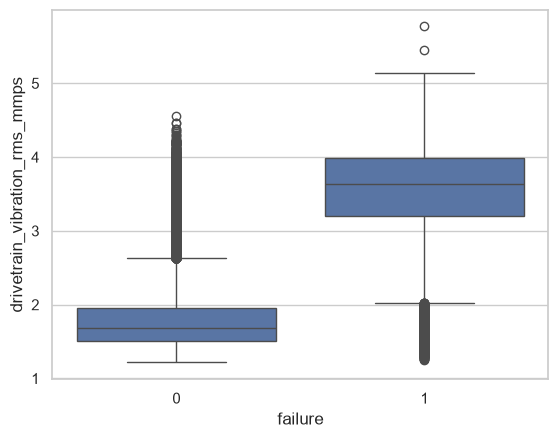

,median,mean,std,min,max
failure,,,,,
0,1.681,1.786054,0.413217,1.216,4.562
1,3.635,3.406979,0.883543,1.254,5.770


**Observation:** drivetrain_vibration_rms_mmps: normal median 1.681, fault median 3.635; standard deviations 0.413 and 0.884. Overlap and outliers mean this is not a standalone fault threshold.

In [27]:
boxplot(data, 'failure', 'drivetrain_vibration_rms_mmps')

**Observation:** drivetrain_vibration_rms_mmps: normal median 1.681, fault median 3.635; standard deviations 0.413 and 0.884. Overlap and outliers mean this is not a standalone fault threshold.

### `oil_particle_count` vs `failure`

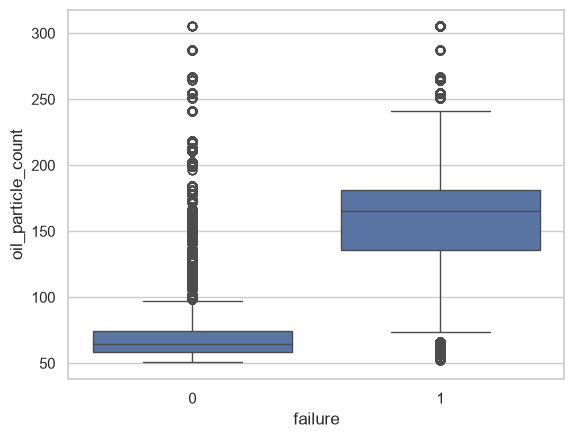

,median,mean,std,min,max
failure,,,,,
0,64.450,71.118184,25.314826,50.565,305.105
1,165.209,158.083293,69.222314,52.507,305.105


**Observation:** oil_particle_count: normal median 64.450, fault median 165.209; standard deviations 25.315 and 69.222. Overlap and outliers mean this is not a standalone fault threshold.

In [28]:
boxplot(data, 'failure', 'oil_particle_count')

**Observation:** oil_particle_count: normal median 64.450, fault median 165.209; standard deviations 25.315 and 69.222. Overlap and outliers mean this is not a standalone fault threshold.

### `gearbox_bearing_temp_C` vs `failure`

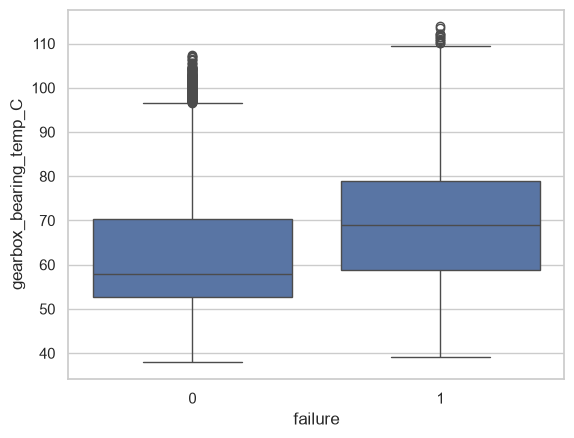

,median,mean,std,min,max
failure,,,,,
0,57.935,62.480469,13.214406,37.901,107.352
1,69.072,70.248516,14.242019,39.025,113.862


**Observation:** gearbox_bearing_temp_C: normal median 57.935, fault median 69.072; standard deviations 13.214 and 14.242. Overlap and outliers mean this is not a standalone fault threshold.

In [29]:
boxplot(data, 'failure', 'gearbox_bearing_temp_C')

**Observation:** gearbox_bearing_temp_C: normal median 57.935, fault median 69.072; standard deviations 13.214 and 14.242. Overlap and outliers mean this is not a standalone fault threshold.

### `power_output_kW` vs `failure`

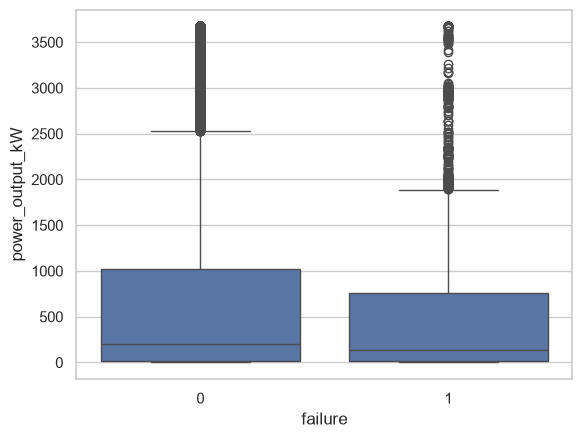

,median,mean,std,min,max
failure,,,,,
0,200.885,636.598587,871.489233,0.0,3672.0
1,136.675,536.909617,800.100828,0.0,3672.0


**Observation:** power_output_kW: normal median 200.885, fault median 136.675; standard deviations 871.489 and 800.101. Overlap and outliers mean this is not a standalone fault threshold.

In [30]:
boxplot(data, 'failure', 'power_output_kW')

**Observation:** power_output_kW: normal median 200.885, fault median 136.675; standard deviations 871.489 and 800.101. Overlap and outliers mean this is not a standalone fault threshold.

### `prior_fault_count` vs `failure`

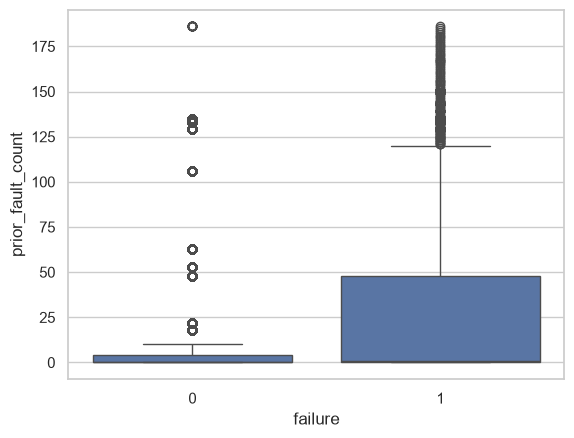

,median,mean,std,min,max
failure,,,,,
0,0.0,14.191132,33.930973,0,186
1,1.0,33.615229,50.368736,0,186


**Observation:** prior_fault_count: normal median 0.000, fault median 1.000; standard deviations 33.931 and 50.369. Overlap and outliers mean this is not a standalone fault threshold.

In [31]:
boxplot(data, 'failure', 'prior_fault_count')

**Observation:** prior_fault_count: normal median 0.000, fault median 1.000; standard deviations 33.931 and 50.369. Overlap and outliers mean this is not a standalone fault threshold.

### ```failure``` vs ```hour```

,failure_pct
hour,
0,2.313297
1,2.622951
2,2.677596
3,2.896175
4,2.987250
5,2.969035
6,2.877960
7,2.622951
8,3.096539


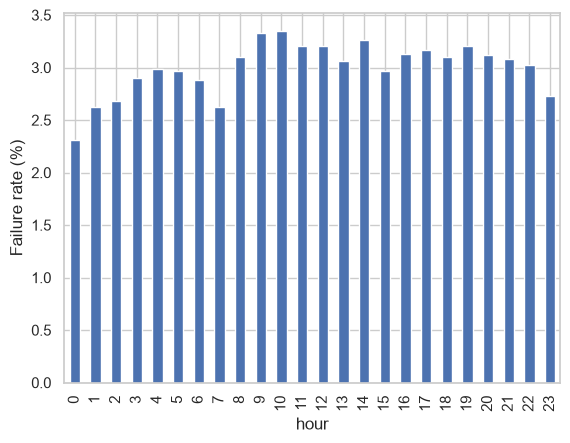

**Observation:** Highest: 10 (3.352%); lowest: 0 (2.313%). These are descriptive associations, not evidence that calendar time causes faults.

In [32]:
rates = data.groupby('hour').failure.mean().mul(100).sort_index()
display(rates.rename('failure_pct').to_frame())
rates.plot.bar(ylabel='Failure rate (%)'); plt.show()
observation(f'Highest: {rates.idxmax()} ({rates.max():.3f}%); lowest: {rates.idxmin()} ({rates.min():.3f}%). These are descriptive associations, not evidence that calendar time causes faults.')

**Observation:** Highest: 10 (3.352%); lowest: 0 (2.313%). These are descriptive associations, not evidence that calendar time causes faults.

### ```failure``` vs ```dayofweek```

,failure_pct
dayofweek,
0,1.522634
1,3.636831
2,2.762346
3,3.245885
4,4.660494
5,3.813657
6,1.255787


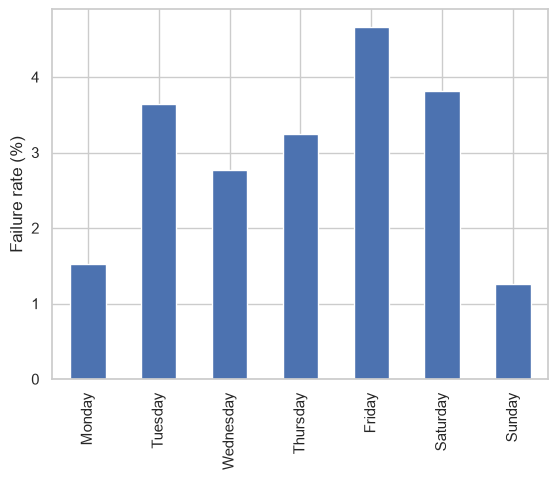

**Observation:** Highest: Friday (4.660%); lowest: Sunday (1.256%). These are descriptive associations, not evidence that calendar time causes faults.

In [33]:
rates = data.groupby('dayofweek').failure.mean().mul(100).sort_index()
display(rates.rename('failure_pct').to_frame())
rates.index = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
rates.plot.bar(ylabel='Failure rate (%)'); plt.show()
observation(f'Highest: {rates.idxmax()} ({rates.max():.3f}%); lowest: {rates.idxmin()} ({rates.min():.3f}%). These are descriptive associations, not evidence that calendar time causes faults.')

**Observation:** Highest: Friday (4.660%); lowest: Sunday (1.256%). These are descriptive associations, not evidence that calendar time causes faults.

## Multivariate Analysis

### Correlation Analysis

In [34]:
numeric_features = data.select_dtypes(include='number').columns.tolist()
print(numeric_features)

['rated_power_kW', 'wind_speed_mps', 'wind_direction_deg', 'turbulence_intensity', 'air_density_kgm3', 'ambient_temp_C', 'humidity_pct', 'power_output_kW', 'rotor_speed_rpm', 'generator_speed_rpm', 'blade_pitch_angle_deg', 'yaw_misalignment_deg', 'gearbox_oil_temp_C', 'gearbox_bearing_temp_C', 'generator_bearing_temp_C', 'generator_winding_temp_C', 'main_bearing_temp_C', 'nacelle_temp_C', 'drivetrain_vibration_rms_mmps', 'tower_vibration_mmps', 'vib_fft_bearing_bpfo', 'vib_fft_bearing_bpfi', 'vib_fft_gearmesh', 'vib_fft_sideband', 'oil_particle_count', 'oil_pressure_bar', 'operating_hours_total', 'cumulative_energy_MWh', 'load_cycles', 'hours_since_last_maintenance', 'prior_fault_count', 'component_age_days', 'failure', 'dayofweek', 'hour']


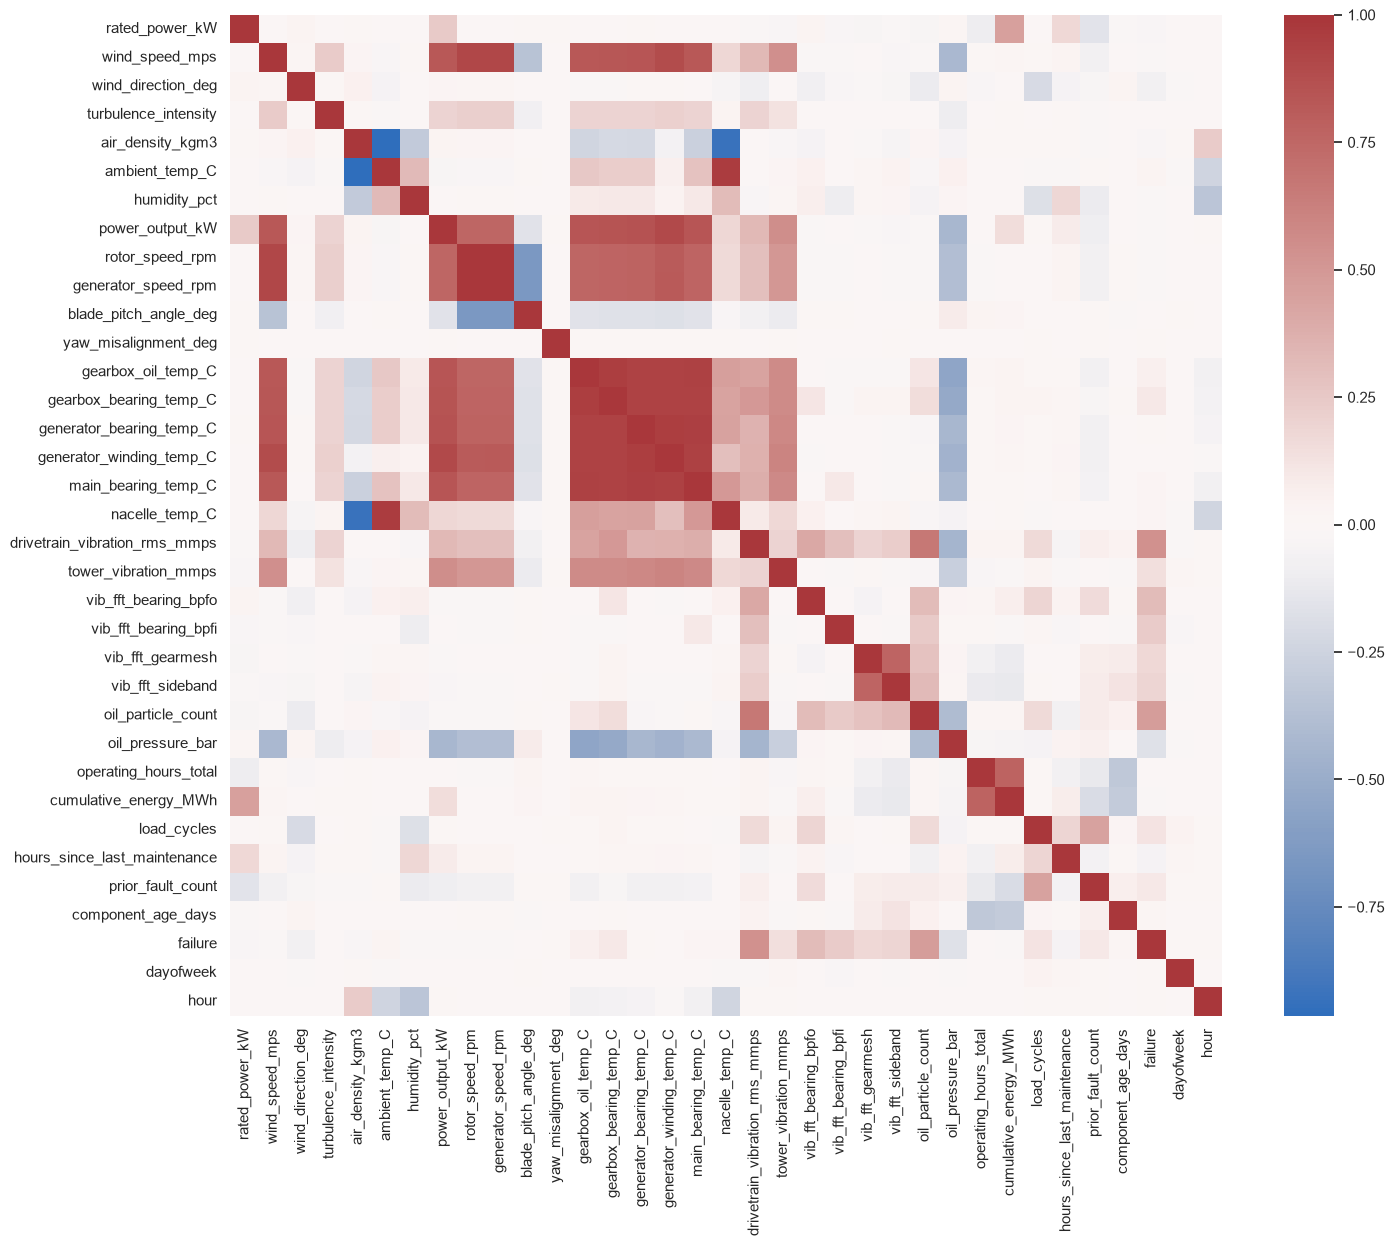

air_density_kgm3          ambient_temp_C             -0.963602
                          nacelle_temp_C             -0.928083
power_output_kW           generator_winding_temp_C    0.904722
wind_speed_mps            rotor_speed_rpm             0.911291
                          generator_speed_rpm         0.911398
gearbox_bearing_temp_C    generator_bearing_temp_C    0.934677
                          main_bearing_temp_C         0.935207
gearbox_oil_temp_C        generator_winding_temp_C    0.936693
gearbox_bearing_temp_C    generator_winding_temp_C    0.937254
gearbox_oil_temp_C        generator_bearing_temp_C    0.938033
                          main_bearing_temp_C         0.940823
generator_winding_temp_C  main_bearing_temp_C         0.943433
generator_bearing_temp_C  main_bearing_temp_C         0.951703
                          generator_winding_temp_C    0.958236
gearbox_oil_temp_C        gearbox_bearing_temp_C      0.960224
ambient_temp_C            nacelle_temp_C              0

In [35]:
corr = data[numeric_features].corr()
plt.figure(figsize=(16,13)); sns.heatmap(corr, cmap='vlag', center=0); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().rename('correlation')
display(pairs[pairs.abs() >= .9].sort_values())

**Observations:** Highly correlated speed and condition channels indicate redundancy. The existing engineered-feature selection is retained for model inputs; correlations describe association and are not causal importance.

# **Data Preprocessing**

## Splitting the data into train, validation, and test sets

This data is **panel time-series**: 15 turbines, each logged every 10 minutes over two months, and a single degradation episode spans many consecutive rows. A random split would scatter rows from the same episode across train and test, letting the model effectively see failures it is later scored on - inflating every metric.


In [36]:
data = data.sort_values(['timestamp','turbine_id'])

In [37]:
n = len(data)
print('Total records:', n)

Total records: 131760


In [38]:
# Preserve the established grouped test and temporal validation protocol.
raw_source = pd.read_csv(root / 'data/raw/wind_turbine_detection.csv', parse_dates=['timestamp'])
metadata = {s: pd.read_csv(root / f'data/processed/03_{s}_metadata.csv', parse_dates=['timestamp']) for s in ['train','validation','test']}
raw_parts = {s: raw_source.merge(m[['turbine_id','timestamp']], on=['turbine_id','timestamp'], validate='one_to_one') for s,m in metadata.items()}
assert not set(metadata['test'].turbine_id) & (set(metadata['train'].turbine_id) | set(metadata['validation'].turbine_id))
for turbine in metadata['train'].turbine_id.unique():
    assert metadata['train'].query('turbine_id == @turbine').timestamp.max() < metadata['validation'].query('turbine_id == @turbine').timestamp.min()
display(pd.DataFrame({s: {'rows': len(p), 'turbines': p.turbine_id.nunique(), 'failure_pct': p.failure.mean()*100} for s,p in raw_parts.items()}).T)


,rows,turbines,failure_pct
train,84336.0,12.0,2.225621
validation,21072.0,12.0,7.047267
test,26352.0,3.0,2.242714


**Observations:** Adaptation: three entire turbines form the test set; earlier/later records from the other turbines form train/validation. This preserves the existing evaluation design and protects against shared turbine identity in test. It measures unseen-turbine generalization rather than the template’s global future-period split. Earlier test exposure remains a limitation.

In [39]:
# Reuse the existing selected snapshot and past-only engineered features.
# Feature-group selection previously used validation data; this reuse is disclosed.
selected_features = pd.read_csv(root / 'reports/model_results/04_selected_features.csv').feature.tolist()
engineered = {s: pd.read_csv(root / f'data/processed/04_{s}_engineered.csv') for s in raw_parts}
X_train, X_valid, X_test = [engineered[s][selected_features].copy() for s in ['train','validation','test']]
y_train, y_valid, y_test = [engineered[s].failure.copy() for s in ['train','validation','test']]
for s, frame in engineered.items():
    assert set(frame.source_index) == set(metadata[s].source_index)
    labels = metadata[s].set_index('source_index').failure.loc[frame.source_index].to_numpy()
    assert np.array_equal(frame.failure, labels)
print('Selected engineered predictors:', selected_features)


Selected engineered predictors: ['rated_power_kW', 'wind_speed_mps', 'wind_direction_deg', 'turbulence_intensity', 'air_density_kgm3', 'ambient_temp_C', 'humidity_pct', 'power_output_kW', 'rotor_speed_rpm', 'generator_speed_rpm', 'blade_pitch_angle_deg', 'yaw_misalignment_deg', 'gearbox_oil_temp_C', 'gearbox_bearing_temp_C', 'generator_bearing_temp_C', 'generator_winding_temp_C', 'main_bearing_temp_C', 'nacelle_temp_C', 'drivetrain_vibration_rms_mmps', 'tower_vibration_mmps', 'vib_fft_bearing_bpfo', 'vib_fft_bearing_bpfi', 'vib_fft_gearmesh', 'vib_fft_sideband', 'oil_particle_count', 'oil_pressure_bar', 'capacity_factor', 'generator_rotor_ratio', 'rotor_stopped', 'gearbox_temp_rise', 'main_bearing_temp_rise', 'generator_winding_temp_rise', 'gearbox_nacelle_temp_gap', 'winding_bearing_temp_gap', 'fft_mean', 'fft_max', 'fft_spread', 'bearing_fft_sum', 'gearmesh_sideband_ratio', 'vibration_per_rotor_rpm', 'oil_particles_per_pressure', 'wind_direction_sin', 'wind_direction_cos', 'yaw_misal

In [40]:
print(f'Train split failure rate: {y_train.mean()*100:.2f}%')
print(f'Validation split failure rate: {y_valid.mean()*100:.2f}%')
print(f'Test split failure rate: {y_test.mean()*100:.2f}%')

Train split failure rate: 2.23%
Validation split failure rate: 7.05%
Test split failure rate: 2.24%


## Missing Value Treatment

### Display the percentage of missing values

In [41]:
display(pd.DataFrame({s:p.isna().mean()*100 for s,p in raw_parts.items()}).rename_axis('feature'))

,train,validation,test
feature,,,
timestamp,0.000000,0.000000,0.000000
turbine_id,0.000000,0.000000,0.000000
rated_power_kW,0.000000,0.000000,0.000000
wind_speed_mps,0.000000,0.000000,0.000000
wind_direction_deg,0.000000,0.000000,0.000000
turbulence_intensity,0.000000,0.000000,0.000000
air_density_kgm3,0.000000,0.000000,0.000000
ambient_temp_C,0.000000,0.000000,0.000000
humidity_pct,0.000000,0.000000,0.000000


### `gearbox_oil_temp_C`

In [42]:
fill_value = raw_parts['train']['gearbox_oil_temp_C'].median()
for part in raw_parts.values(): part['gearbox_oil_temp_C'] = part['gearbox_oil_temp_C'].fillna(fill_value)
print('gearbox_oil_temp_C', 'training median:', fill_value)
assert all(p['gearbox_oil_temp_C'].isna().sum() == 0 for p in raw_parts.values())

gearbox_oil_temp_C training median: 53.996


**Observations:** Median imputation is robust to extreme values. The same training-derived value is used in every partition. These raw-sensor values are imputed separately; the selected engineered predictors below receive their own training-fitted pipeline imputer, including inside cross-validation.

### ```generator_bearing_temp_C```

In [43]:
fill_value = raw_parts['train']['generator_bearing_temp_C'].median()
for part in raw_parts.values(): part['generator_bearing_temp_C'] = part['generator_bearing_temp_C'].fillna(fill_value)
print('generator_bearing_temp_C', 'training median:', fill_value)
assert all(p['generator_bearing_temp_C'].isna().sum() == 0 for p in raw_parts.values())

generator_bearing_temp_C training median: 58.107


**Observations:** Median imputation is robust to extreme values. The same training-derived value is used in every partition. These raw-sensor values are imputed separately; the selected engineered predictors below receive their own training-fitted pipeline imputer, including inside cross-validation.

### ```oil_pressure_bar```

In [44]:
fill_value = raw_parts['train']['oil_pressure_bar'].median()
for part in raw_parts.values(): part['oil_pressure_bar'] = part['oil_pressure_bar'].fillna(fill_value)
print('oil_pressure_bar', 'training median:', fill_value)
assert all(p['oil_pressure_bar'].isna().sum() == 0 for p in raw_parts.values())

oil_pressure_bar training median: 5.911


**Observations:** Median imputation is robust to extreme values. The same training-derived value is used in every partition. These raw-sensor values are imputed separately; the selected engineered predictors below receive their own training-fitted pipeline imputer, including inside cross-validation.

# **Model Building**

Decision Tree, Random Forest, Gradient Boosting, XGBoost, and a neural network are evaluated on the training and validation partitions.

## Model Evaluation Criterion

In [45]:
metric_of_choice = 'recall'
print('Primary objective: catch faults (recall); PR-AUC and precision assess false-alert tradeoffs.')

Primary objective: catch faults (recall); PR-AUC and precision assess false-alert tradeoffs.


## Utility Functions

Evaluation reports accuracy, recall, precision, F1, F2, PR-AUC, and ROC-AUC. Confusion matrices show missed faults and false alerts at the common 0.50 threshold.

In [46]:
def probabilities(model, X):
    if hasattr(model, 'predict_proba'): return model.predict_proba(X)[:,1]
    return model.predict(dataset(np.asarray(X, dtype='float32')), verbose=0).ravel()
def scores(y, p, threshold=.5):
    pred = np.asarray(p) >= threshold
    return dict(Accuracy=accuracy_score(y,pred), Recall=recall_score(y,pred,zero_division=0), Precision=precision_score(y,pred,zero_division=0), F1=f1_score(y,pred,zero_division=0), F2=fbeta_score(y,pred,beta=2,zero_division=0), PR_AUC=average_precision_score(y,p), ROC_AUC=roc_auc_score(y,p))
records, fitted, validation_probabilities = [], {}, {}
def evaluate(name, model, train_x=X_train, valid_x=X_valid):
    fitted[name] = model
    fig, axes = plt.subplots(1,2,figsize=(10,4))
    local = []
    for ax, split, x, y in [(axes[0],'train',train_x,y_train),(axes[1],'validation',valid_x,y_valid)]:
        p = probabilities(model,x)
        row = dict(model=name,split=split,**scores(y,p)); records.append(row); local.append(row)
        ConfusionMatrixDisplay.from_predictions(y,p>=.5,ax=ax,colorbar=False)
        ax.set_title(name+' / '+split)
        if split == 'validation': validation_probabilities[name] = p
    plt.tight_layout(); plt.show(); display(pd.DataFrame(local))
    observation(f"Train/validation recall {local[0]['Recall']:.3f}/{local[1]['Recall']:.3f}, PR-AUC {local[0]['PR_AUC']:.3f}/{local[1]['PR_AUC']:.3f}. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.")
def tree_pipeline(model): return Pipeline([('imputer',SimpleImputer(strategy='median')),('model',model)])


In [47]:
def plot_confusion_matrix(model, predictors, target):
    ConfusionMatrixDisplay.from_predictions(target, probabilities(model,predictors)>=.5); plt.show()

## Decision Tree Classifier

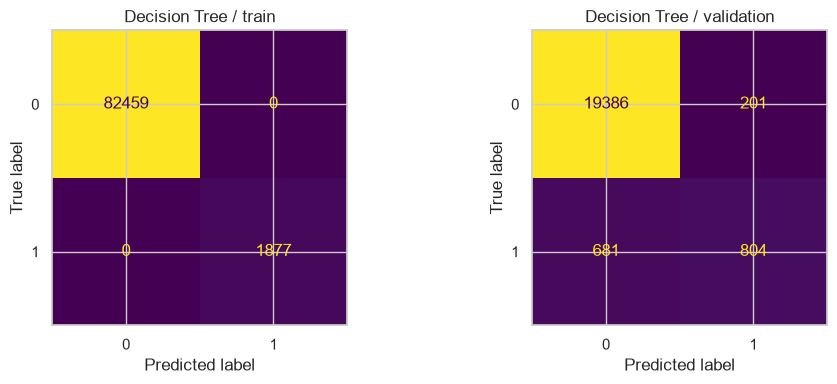

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Decision Tree,train,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,validation,0.958144,0.541414,0.8,0.645783,0.578834,0.465449,0.765576


**Observation:** Train/validation recall 1.000/0.541, PR-AUC 1.000/0.465. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [48]:
model = tree_pipeline(DecisionTreeClassifier(class_weight='balanced', random_state=42))
model.fit(X_train,y_train)
evaluate('Decision Tree',model)

**Observation:** Train/validation recall 1.000/0.541, PR-AUC 1.000/0.465. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

## Random Forest Classifier

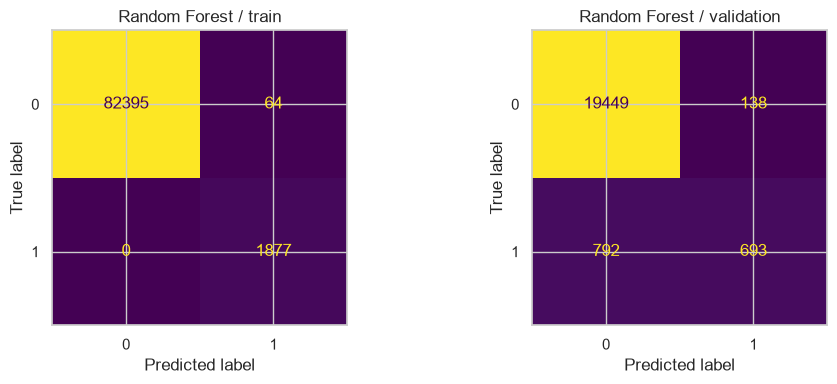

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Random Forest,train,0.999241,1.000000,0.967027,0.983237,0.993227,1.000000,1.000000
1,Random Forest,validation,0.955866,0.466667,0.833935,0.598446,0.511741,0.775711,0.979478


**Observation:** Train/validation recall 1.000/0.467, PR-AUC 1.000/0.776. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [49]:
model = tree_pipeline(RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=2))
model.fit(X_train,y_train)
evaluate('Random Forest',model)

**Observation:** Train/validation recall 1.000/0.467, PR-AUC 1.000/0.776. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

## Gradient Boosting Classifier

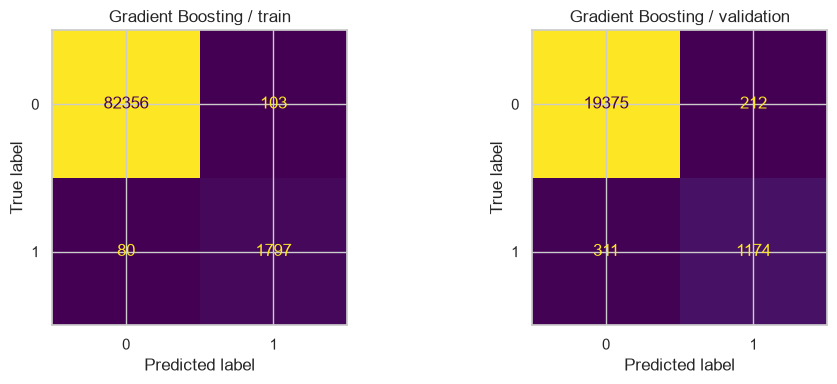

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Gradient Boosting,train,0.99783,0.957379,0.945789,0.951549,0.955038,0.992021,0.999816
1,Gradient Boosting,validation,0.97518,0.790572,0.847042,0.817834,0.801256,0.890337,0.991748


**Observation:** Train/validation recall 0.957/0.791, PR-AUC 0.992/0.890. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [50]:
model = tree_pipeline(GradientBoostingClassifier(n_estimators=100, random_state=42))
model.fit(X_train,y_train)
evaluate('Gradient Boosting',model)

**Observation:** Train/validation recall 0.957/0.791, PR-AUC 0.992/0.890. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

## XGBoost

Negative / positive training ratio: 43.93127330847096


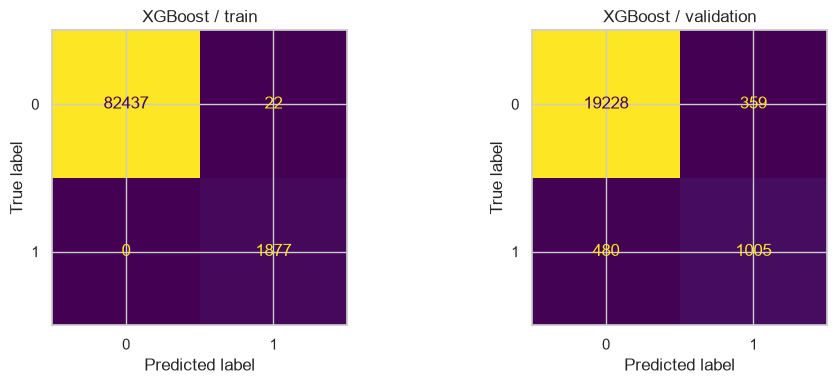

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,XGBoost,train,0.999739,1.000000,0.988415,0.994174,0.997661,1.000000,1.000000
1,XGBoost,validation,0.960184,0.676768,0.736804,0.705511,0.687979,0.811938,0.979535


**Observation:** Train/validation recall 1.000/0.677, PR-AUC 1.000/0.812. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [51]:
print('Negative / positive training ratio:', (y_train==0).sum()/(y_train==1).sum())
model = tree_pipeline(BalancedXGBClassifier(n_estimators=150,max_depth=6,learning_rate=.1,random_state=42,n_jobs=2,eval_metric='logloss'))
model.fit(X_train,y_train)
evaluate('XGBoost',model)

**Observation:** Train/validation recall 1.000/0.677, PR-AUC 1.000/0.812. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

## Neural Networks(ANN)

In [52]:
tf.keras.backend.clear_session()

In [53]:
ann_transform = Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
X_train_scaled = ann_transform.fit_transform(X_train).astype('float32')
X_valid_scaled = ann_transform.transform(X_valid).astype('float32')
X_test_scaled = ann_transform.transform(X_test).astype('float32')

In [54]:
keras.utils.set_random_seed(42)
model = keras.Sequential([keras.layers.Input((X_train_scaled.shape[1],)),keras.layers.Dense(64,activation='relu'),keras.layers.Dense(1,activation='sigmoid')])

In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633 (22.00 KB)

 Trainable params: 5,633 (22.00 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model.compile(optimizer=keras.optimizers.Adam(.001), loss='binary_crossentropy', metrics=[keras.metrics.Recall(name='recall'),keras.metrics.Precision(name='precision'),keras.metrics.BinaryAccuracy(name='accuracy')])

In [57]:
epochs = 30
batch_size = 128

In [58]:
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = dict(enumerate(weights))
sample_weights = np.array([class_weight_dict[int(v)] for v in y_train], dtype='float32')

In [59]:
start=time.time()
history=model.fit(dataset(X_train_scaled,y_train.to_numpy(),batch_size,sample_weights,True),validation_data=dataset(X_valid_scaled,y_valid.to_numpy()),epochs=epochs,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)])
end=time.time()

Epoch 1/30


/Users/namees.local/Desktop/Wind Turbine Failure Detection/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


659/659 - 1s - 1ms/step - accuracy: 0.9492 - loss: 0.0918 - precision: 0.3036 - recall: 0.9920 - val_accuracy: 0.9260 - val_loss: 0.2021 - val_precision: 0.4874 - val_recall: 0.9603


Epoch 2/30


659/659 - 0s - 422us/step - accuracy: 0.9770 - loss: 0.0432 - precision: 0.4916 - recall: 0.9973 - val_accuracy: 0.9280 - val_loss: 0.2083 - val_precision: 0.4944 - val_recall: 0.9724


Epoch 3/30


659/659 - 0s - 418us/step - accuracy: 0.9806 - loss: 0.0349 - precision: 0.5345 - recall: 1.0000 - val_accuracy: 0.9302 - val_loss: 0.2168 - val_precision: 0.5024 - val_recall: 0.9751


Epoch 4/30


659/659 - 0s - 418us/step - accuracy: 0.9826 - loss: 0.0314 - precision: 0.5612 - recall: 0.9984 - val_accuracy: 0.9369 - val_loss: 0.1864 - val_precision: 0.5290 - val_recall: 0.9529


Epoch 5/30


659/659 - 0s - 421us/step - accuracy: 0.9848 - loss: 0.0296 - precision: 0.5949 - recall: 0.9989 - val_accuracy: 0.9336 - val_loss: 0.2121 - val_precision: 0.5154 - val_recall: 0.9569


Epoch 6/30


659/659 - 0s - 431us/step - accuracy: 0.9872 - loss: 0.0240 - precision: 0.6355 - recall: 0.9995 - val_accuracy: 0.9356 - val_loss: 0.1935 - val_precision: 0.5246 - val_recall: 0.9279


Epoch 7/30


659/659 - 0s - 427us/step - accuracy: 0.9876 - loss: 0.0245 - precision: 0.6418 - recall: 0.9995 - val_accuracy: 0.9466 - val_loss: 0.1553 - val_precision: 0.5767 - val_recall: 0.9118


Epoch 8/30


659/659 - 0s - 416us/step - accuracy: 0.9896 - loss: 0.0207 - precision: 0.6806 - recall: 1.0000 - val_accuracy: 0.9327 - val_loss: 0.2887 - val_precision: 0.5123 - val_recall: 0.9253


Epoch 9/30


659/659 - 0s - 417us/step - accuracy: 0.9893 - loss: 0.0218 - precision: 0.6758 - recall: 0.9995 - val_accuracy: 0.9388 - val_loss: 0.2145 - val_precision: 0.5374 - val_recall: 0.9481


Epoch 10/30


659/659 - 0s - 419us/step - accuracy: 0.9902 - loss: 0.0208 - precision: 0.6942 - recall: 0.9989 - val_accuracy: 0.9314 - val_loss: 0.2954 - val_precision: 0.5074 - val_recall: 0.9185


Epoch 11/30


659/659 - 0s - 417us/step - accuracy: 0.9913 - loss: 0.0182 - precision: 0.7200 - recall: 1.0000 - val_accuracy: 0.9407 - val_loss: 0.1982 - val_precision: 0.5478 - val_recall: 0.9111


Epoch 12/30


659/659 - 0s - 417us/step - accuracy: 0.9919 - loss: 0.0167 - precision: 0.7344 - recall: 1.0000 - val_accuracy: 0.9352 - val_loss: 0.2528 - val_precision: 0.5235 - val_recall: 0.8990


In [60]:
print("Time taken in seconds ",end-start)

Time taken in seconds  3.954210042953491


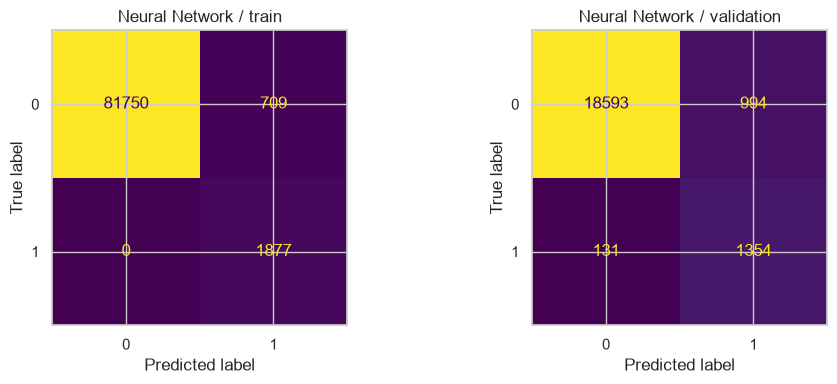

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Neural Network,train,0.991593,1.000000,0.725831,0.841138,0.929760,0.973677,0.999443
1,Neural Network,validation,0.946612,0.911785,0.576661,0.706496,0.816844,0.803558,0.982534


**Observation:** Train/validation recall 1.000/0.912, PR-AUC 0.974/0.804. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

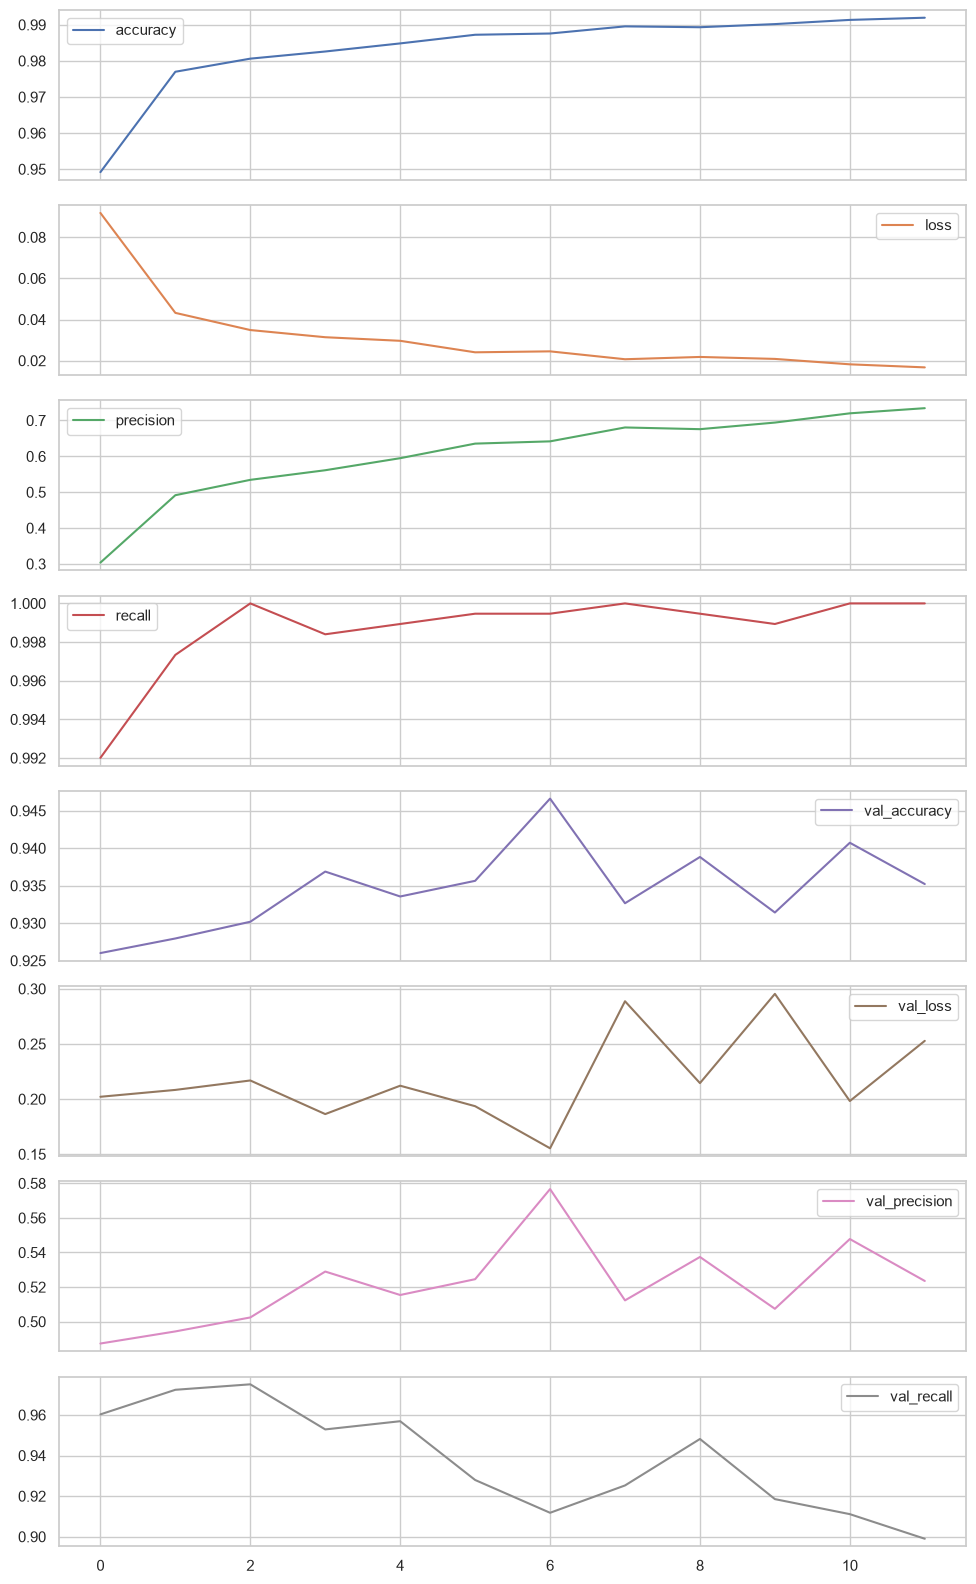

In [61]:
evaluate('Neural Network',model,X_train_scaled,X_valid_scaled)
model.save(output/'baseline_ann.keras')
pd.DataFrame(history.history).plot(subplots=True,figsize=(10,16)); plt.tight_layout(); plt.show()

**Observation:** Train/validation recall 1.000/0.912, PR-AUC 0.974/0.804. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

**Observations:** Metrics are unweighted diagnostic measures; training loss uses class weights and validation loss does not. Early stopping restores the best validation-loss weights. Training allows up to 30 epochs; early stopping can end it sooner.

## **Baseline Model Performance Comparison**

### Training performance comparison

In [62]:
baseline_table = pd.DataFrame(records)
display(baseline_table.query("split == 'train'").sort_values(['Recall','PR_AUC'],ascending=False))

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Decision Tree,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,train,0.999241,1.000000,0.967027,0.983237,0.993227,1.000000,1.000000
6,XGBoost,train,0.999739,1.000000,0.988415,0.994174,0.997661,1.000000,1.000000
8,Neural Network,train,0.991593,1.000000,0.725831,0.841138,0.929760,0.973677,0.999443
4,Gradient Boosting,train,0.997830,0.957379,0.945789,0.951549,0.955038,0.992021,0.999816


### Validation performance comparison

In [63]:
display(baseline_table.query("split == 'validation'").sort_values(['Recall','PR_AUC'],ascending=False))
observation('The top two tree baselines by validation recall, then PR-AUC, are tuned below; the regularized ANN is also evaluated. Selection uses no test metrics.')

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
9,Neural Network,validation,0.946612,0.911785,0.576661,0.706496,0.816844,0.803558,0.982534
5,Gradient Boosting,validation,0.975180,0.790572,0.847042,0.817834,0.801256,0.890337,0.991748
7,XGBoost,validation,0.960184,0.676768,0.736804,0.705511,0.687979,0.811938,0.979535
1,Decision Tree,validation,0.958144,0.541414,0.800000,0.645783,0.578834,0.465449,0.765576
3,Random Forest,validation,0.955866,0.466667,0.833935,0.598446,0.511741,0.775711,0.979478


**Observation:** The top two tree baselines by validation recall, then PR-AUC, are tuned below; the regularized ANN is also evaluated. Selection uses no test metrics.

**Observation:** The top two tree baselines by validation recall, then PR-AUC, are tuned below; the regularized ANN is also evaluated. Selection uses no test metrics.

# **Hyperparameter Tuning**

The two tree families with the highest baseline validation recall, with PR-AUC as the tie-breaker, proceed to randomized search. A regularized neural network is also evaluated. Unselected tree families retain their baseline results.

## XGBoost

In [64]:
tree_names = ['Decision Tree','Random Forest','Gradient Boosting','XGBoost']
tuning_candidates = baseline_table.query("split == 'validation' and model in @tree_names").sort_values(['Recall','PR_AUC'],ascending=False).head(2).model.tolist()
print('Selected tree tuning candidates:', tuning_candidates)
# Five expanding chronological folds for XGB/DT/RF; GB uses three as requested.
timestamps = pd.to_datetime(engineered['train'].timestamp)
unique_times = pd.Index(timestamps.unique()).sort_values()
def temporal_folds(count):
    edges = np.linspace(.4,1,count+1); folds=[]
    for left,right in zip(edges[:-1],edges[1:]):
        lo=unique_times[int(left*len(unique_times))]
        hi=unique_times[min(int(right*len(unique_times)),len(unique_times)-1)]
        tr=np.flatnonzero(timestamps<lo)
        va=np.flatnonzero((timestamps>=lo)&((timestamps<hi) if right<1 else (timestamps<=hi)))
        assert timestamps.iloc[tr].max()<timestamps.iloc[va].min()
        folds.append((tr,va))
    return folds
search_spaces = {'XGBoost':{'n_estimators':[100,200], 'learning_rate':[.03,.1], 'max_depth':[3,6], 'min_child_weight':[1,5], 'gamma':[0,.2], 'subsample':[.8,1.], 'colsample_bytree':[.8,1.], 'reg_alpha':[0,.1], 'reg_lambda':[1.,5.]},
'Decision Tree':{'criterion':['gini','entropy'],'max_depth':[5,10,20],'min_samples_split':[2,10],'min_samples_leaf':[1,5,10],'max_features':['sqrt','log2']},
'Random Forest':{'n_estimators':[100,200],'max_depth':[8,16,None],'min_samples_split':[2,10],'min_samples_leaf':[1,5],'max_features':['sqrt','log2']},
'Gradient Boosting':{'n_estimators':[100,150],'learning_rate':[.03,.1],'max_depth':[2,3],'subsample':[.8,1.],'max_features':['sqrt','log2']}}
searches={}
def tune(name):
    if name not in tuning_candidates:
        observation(name+' is not selected for tuning; the template requires at least two selected baseline models.'); return
    folds=temporal_folds(3 if name=='Gradient Boosting' else 5)
    search=RandomizedSearchCV(clone(fitted[name]),{'model__'+k:v for k,v in search_spaces[name].items()},n_iter=4,scoring='recall',cv=folds,refit=True,random_state=42,n_jobs=1,error_score='raise')
    search.fit(X_train,y_train); searches[name]=search
    print('Best parameters:',search.best_params_,'CV recall:',search.best_score_,'folds:',len(folds))
    evaluate(name+' tuned',search.best_estimator_)
display(pd.Series(search_spaces['XGBoost'],name='search_values'))


Selected tree tuning candidates: ['Gradient Boosting', 'XGBoost']


n_estimators         [100, 200]
learning_rate       [0.03, 0.1]
max_depth                [3, 6]
min_child_weight         [1, 5]
gamma                  [0, 0.2]
subsample            [0.8, 1.0]
colsample_bytree     [0.8, 1.0]
reg_alpha              [0, 0.1]
reg_lambda           [1.0, 5.0]
Name: search_values, dtype: object

Best parameters: {'model__subsample': 0.8, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 1.0} CV recall: 0.7582180010827766 folds: 5


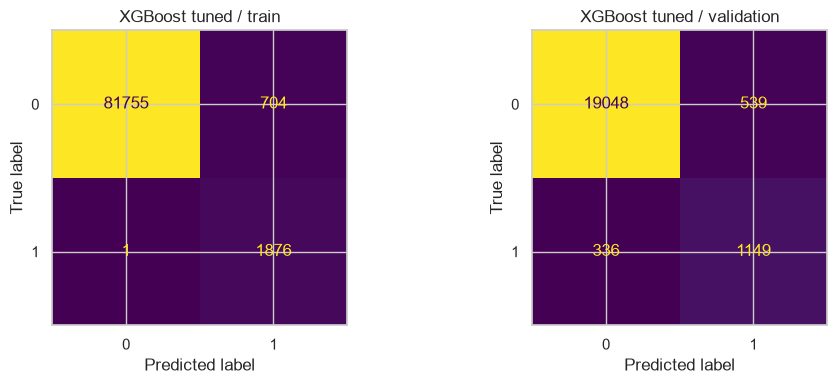

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,XGBoost tuned,train,0.991641,0.999467,0.727132,0.841822,0.929818,0.973193,0.999428
1,XGBoost tuned,validation,0.958476,0.773737,0.680687,0.724236,0.753146,0.824876,0.976667


**Observation:** Train/validation recall 0.999/0.774, PR-AUC 0.973/0.825. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [65]:
tune('XGBoost')

**Observation:** Train/validation recall 0.999/0.774, PR-AUC 0.973/0.825. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [66]:
if 'XGBoost' in searches: display(searches['XGBoost'].best_estimator_)
# RandomizedSearchCV(refit=True) already refits on the complete training set.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](86,)","['rated_power_kW','wind_speed_mps','wind_direction_deg',..., 'oil_pressure_bar_past_1h_std','oil_pressure_bar_past_3h_mean', 'oil_pressure_bar_past_3h_std']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,86
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_

## Neural Networks

In [67]:
tf.keras.backend.clear_session()

In [68]:
keras.utils.set_random_seed(42)
model1 = keras.Sequential([keras.layers.Input((X_train_scaled.shape[1],)),keras.layers.Dense(128,activation='relu'),keras.layers.BatchNormalization(),keras.layers.Dropout(.5),keras.layers.Dense(64,activation='relu'),keras.layers.BatchNormalization(),keras.layers.Dropout(.5),keras.layers.Dense(1,activation='sigmoid')])

In [69]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,225 (79.00 KB)

 Trainable params: 19,841 (77.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [70]:
model1.compile(optimizer=keras.optimizers.Adam(.001), loss='binary_crossentropy', metrics=[keras.metrics.Recall(name='recall'),keras.metrics.Precision(name='precision'),keras.metrics.BinaryAccuracy(name='accuracy')])

In [71]:
epochs = 30
batch_size = 128

In [72]:
start=time.time()
history=model1.fit(dataset(X_train_scaled,y_train.to_numpy(),batch_size,sample_weights,True),validation_data=dataset(X_valid_scaled,y_valid.to_numpy()),epochs=epochs,verbose=2,callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)])
end=time.time()

Epoch 1/30


/Users/namees.local/Desktop/Wind Turbine Failure Detection/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


659/659 - 2s - 2ms/step - accuracy: 0.8722 - loss: 0.2448 - precision: 0.1448 - recall: 0.9670 - val_accuracy: 0.9045 - val_loss: 0.3103 - val_precision: 0.4238 - val_recall: 0.9892


Epoch 2/30


659/659 - 0s - 724us/step - accuracy: 0.9606 - loss: 0.1072 - precision: 0.3592 - recall: 0.9814 - val_accuracy: 0.9010 - val_loss: 0.3675 - val_precision: 0.4153 - val_recall: 0.9933


Epoch 3/30


659/659 - 0s - 755us/step - accuracy: 0.9679 - loss: 0.0864 - precision: 0.4081 - recall: 0.9856 - val_accuracy: 0.9098 - val_loss: 0.3029 - val_precision: 0.4384 - val_recall: 0.9946


Epoch 4/30


659/659 - 0s - 726us/step - accuracy: 0.9728 - loss: 0.0695 - precision: 0.4496 - recall: 0.9909 - val_accuracy: 0.9191 - val_loss: 0.2645 - val_precision: 0.4653 - val_recall: 0.9886


Epoch 5/30


659/659 - 0s - 724us/step - accuracy: 0.9724 - loss: 0.0684 - precision: 0.4462 - recall: 0.9915 - val_accuracy: 0.9100 - val_loss: 0.2960 - val_precision: 0.4387 - val_recall: 0.9906


Epoch 6/30


659/659 - 0s - 727us/step - accuracy: 0.9735 - loss: 0.0655 - precision: 0.4560 - recall: 0.9877 - val_accuracy: 0.9135 - val_loss: 0.2861 - val_precision: 0.4486 - val_recall: 0.9926


Epoch 7/30


659/659 - 0s - 735us/step - accuracy: 0.9748 - loss: 0.0603 - precision: 0.4684 - recall: 0.9899 - val_accuracy: 0.9207 - val_loss: 0.2437 - val_precision: 0.4703 - val_recall: 0.9852


Epoch 8/30


659/659 - 1s - 760us/step - accuracy: 0.9756 - loss: 0.0573 - precision: 0.4763 - recall: 0.9920 - val_accuracy: 0.9204 - val_loss: 0.2467 - val_precision: 0.4693 - val_recall: 0.9933


Epoch 9/30


659/659 - 0s - 725us/step - accuracy: 0.9774 - loss: 0.0525 - precision: 0.4957 - recall: 0.9936 - val_accuracy: 0.9234 - val_loss: 0.2366 - val_precision: 0.4787 - val_recall: 0.9859


Epoch 10/30


659/659 - 0s - 724us/step - accuracy: 0.9778 - loss: 0.0510 - precision: 0.5005 - recall: 0.9952 - val_accuracy: 0.9299 - val_loss: 0.2074 - val_precision: 0.5014 - val_recall: 0.9845


Epoch 11/30


659/659 - 0s - 726us/step - accuracy: 0.9785 - loss: 0.0505 - precision: 0.5082 - recall: 0.9915 - val_accuracy: 0.9225 - val_loss: 0.2503 - val_precision: 0.4758 - val_recall: 0.9778


Epoch 12/30


659/659 - 0s - 724us/step - accuracy: 0.9786 - loss: 0.0498 - precision: 0.5104 - recall: 0.9936 - val_accuracy: 0.9268 - val_loss: 0.2353 - val_precision: 0.4904 - val_recall: 0.9791


Epoch 13/30


659/659 - 0s - 726us/step - accuracy: 0.9790 - loss: 0.0484 - precision: 0.5140 - recall: 0.9941 - val_accuracy: 0.9200 - val_loss: 0.2840 - val_precision: 0.4680 - val_recall: 0.9852


Epoch 14/30


659/659 - 0s - 725us/step - accuracy: 0.9799 - loss: 0.0462 - precision: 0.5263 - recall: 0.9925 - val_accuracy: 0.9211 - val_loss: 0.2812 - val_precision: 0.4713 - val_recall: 0.9845


Epoch 15/30


659/659 - 1s - 765us/step - accuracy: 0.9801 - loss: 0.0468 - precision: 0.5282 - recall: 0.9963 - val_accuracy: 0.9235 - val_loss: 0.2575 - val_precision: 0.4794 - val_recall: 0.9879


In [73]:
print("Time taken in seconds ",end-start)

Time taken in seconds  8.36381196975708


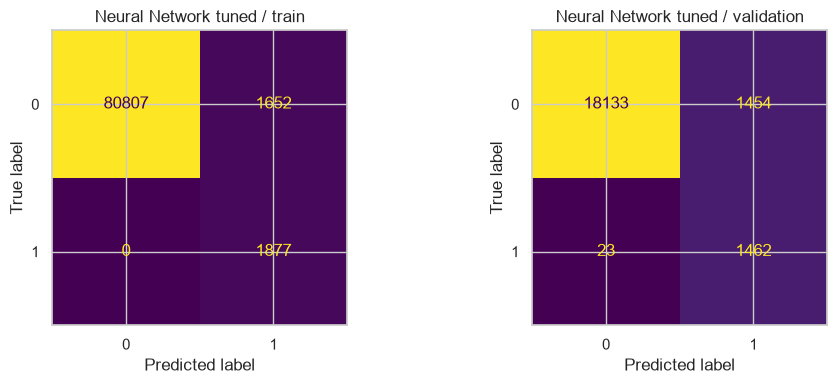

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Neural Network tuned,train,0.980412,1.000000,0.531879,0.694414,0.850322,0.947744,0.998948
1,Neural Network tuned,validation,0.929907,0.984512,0.501372,0.664394,0.825429,0.859333,0.989650


**Observation:** Train/validation recall 1.000/0.985, PR-AUC 0.948/0.859. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

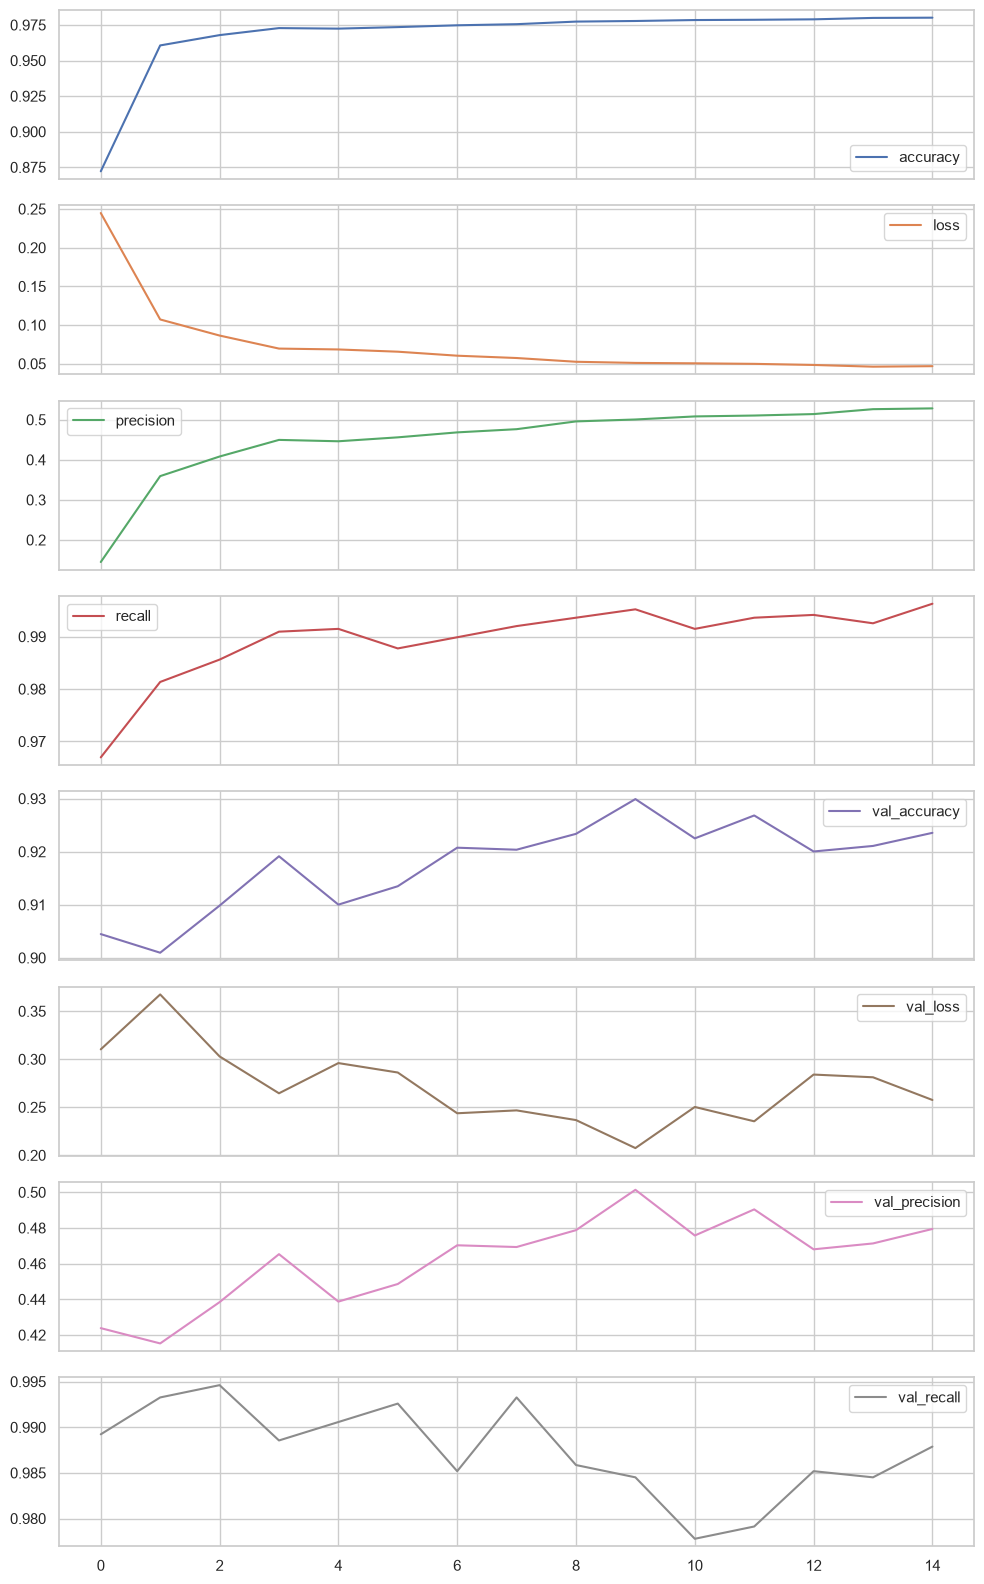

In [74]:
evaluate('Neural Network tuned',model1,X_train_scaled,X_valid_scaled)
model1.save(output/'tuned_ann.keras')
pd.DataFrame(history.history).plot(subplots=True,figsize=(10,16)); plt.tight_layout(); plt.show()

**Observation:** Train/validation recall 1.000/0.985, PR-AUC 0.948/0.859. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

## Decision Tree

In [75]:
display(pd.Series(search_spaces['Decision Tree'],name='search_values'))

criterion            [gini, entropy]
max_depth                [5, 10, 20]
min_samples_split            [2, 10]
min_samples_leaf          [1, 5, 10]
max_features            [sqrt, log2]
Name: search_values, dtype: object

In [76]:
tune('Decision Tree')

**Observation:** Decision Tree is not selected for tuning; the template requires at least two selected baseline models.

**Observation:** Decision Tree is not selected for tuning; the template requires at least two selected baseline models.

In [77]:
if 'Decision Tree' in searches: display(searches['Decision Tree'].best_estimator_)
# Full-training refit and train/validation evaluation are performed by tune().

In [78]:
display(pd.DataFrame(records).query("model == 'Decision Tree tuned' and split == 'train'"))

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC


In [79]:
display(pd.DataFrame(records).query("model == 'Decision Tree tuned' and split == 'validation'"))

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC


## Random Forest

In [80]:
display(pd.Series(search_spaces['Random Forest'],name='search_values'))

n_estimators            [100, 200]
max_depth            [8, 16, None]
min_samples_split          [2, 10]
min_samples_leaf            [1, 5]
max_features          [sqrt, log2]
Name: search_values, dtype: object

In [81]:
tune('Random Forest')

**Observation:** Random Forest is not selected for tuning; the template requires at least two selected baseline models.

**Observation:** Random Forest is not selected for tuning; the template requires at least two selected baseline models.

In [82]:
if 'Random Forest' in searches: display(searches['Random Forest'].best_estimator_)
# Full-training refit and train/validation evaluation are performed by tune().

## Gradient Boosting

In [83]:
display(pd.Series(search_spaces['Gradient Boosting'],name='search_values'))

n_estimators       [100, 150]
learning_rate     [0.03, 0.1]
max_depth              [2, 3]
subsample          [0.8, 1.0]
max_features     [sqrt, log2]
Name: search_values, dtype: object

Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_features': 'sqrt', 'model__max_depth': 2, 'model__learning_rate': 0.1} CV recall: 0.7497901335909645 folds: 3


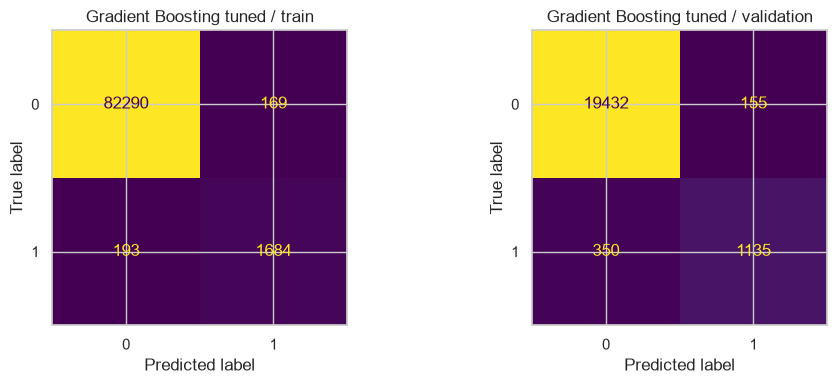

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Gradient Boosting tuned,train,0.995708,0.897176,0.908797,0.902949,0.899477,0.964429,0.999185
1,Gradient Boosting tuned,validation,0.976035,0.764310,0.879845,0.818018,0.784924,0.869973,0.992732


**Observation:** Train/validation recall 0.897/0.764, PR-AUC 0.964/0.870. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [84]:
tune('Gradient Boosting')

**Observation:** Train/validation recall 0.897/0.764, PR-AUC 0.964/0.870. A training advantage is evidence of a generalization gap, not proof that tuning will improve validation results.

In [85]:
if 'Gradient Boosting' in searches: display(searches['Gradient Boosting'].best_estimator_)
# Full-training refit and train/validation evaluation are performed by tune().

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](86,)","['rated_power_kW','wind_speed_mps','wind_direction_deg',..., 'oil_pressure_bar_past_1h_std','oil_pressure_bar_past_3h_mean', 'oil_pressure_bar_past_3h_std']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,86
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_

# **Final Model Selection**

In [86]:
all_results = pd.DataFrame(records)
display(all_results.query("split == 'train'").sort_values(['Recall','PR_AUC'],ascending=False))

,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Decision Tree,train,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,train,0.999241,1.000000,0.967027,0.983237,0.993227,1.000000,1.000000
6,XGBoost,train,0.999739,1.000000,0.988415,0.994174,0.997661,1.000000,1.000000
8,Neural Network,train,0.991593,1.000000,0.725831,0.841138,0.929760,0.973677,0.999443
12,Neural Network tuned,train,0.980412,1.000000,0.531879,0.694414,0.850322,0.947744,0.998948
10,XGBoost tuned,train,0.991641,0.999467,0.727132,0.841822,0.929818,0.973193,0.999428
4,Gradient Boosting,train,0.997830,0.957379,0.945789,0.951549,0.955038,0.992021,0.999816
14,Gradient Boosting tuned,train,0.995708,0.897176,0.908797,0.902949,0.899477,0.964429,0.999185


In [87]:
display(all_results.query("split == 'validation'").sort_values(['Recall','PR_AUC'],ascending=False))
for name in tuning_candidates + ['Neural Network']:
    rows=all_results.query("split == 'validation'").set_index('model')
    observation(f"{name}: tuning changes recall by {rows.loc[name+' tuned','Recall']-rows.loc[name,'Recall']:+.4f} and PR-AUC by {rows.loc[name+' tuned','PR_AUC']-rows.loc[name,'PR_AUC']:+.4f} at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.")


,model,split,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
13,Neural Network tuned,validation,0.929907,0.984512,0.501372,0.664394,0.825429,0.859333,0.989650
9,Neural Network,validation,0.946612,0.911785,0.576661,0.706496,0.816844,0.803558,0.982534
5,Gradient Boosting,validation,0.975180,0.790572,0.847042,0.817834,0.801256,0.890337,0.991748
11,XGBoost tuned,validation,0.958476,0.773737,0.680687,0.724236,0.753146,0.824876,0.976667
15,Gradient Boosting tuned,validation,0.976035,0.764310,0.879845,0.818018,0.784924,0.869973,0.992732
7,XGBoost,validation,0.960184,0.676768,0.736804,0.705511,0.687979,0.811938,0.979535
1,Decision Tree,validation,0.958144,0.541414,0.800000,0.645783,0.578834,0.465449,0.765576
3,Random Forest,validation,0.955866,0.466667,0.833935,0.598446,0.511741,0.775711,0.979478


**Observation:** Gradient Boosting: tuning changes recall by -0.0263 and PR-AUC by -0.0204 at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.

**Observation:** XGBoost: tuning changes recall by +0.0970 and PR-AUC by +0.0129 at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.

**Observation:** Neural Network: tuning changes recall by +0.0727 and PR-AUC by +0.0558 at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.

**Observation:** Gradient Boosting: tuning changes recall by -0.0263 and PR-AUC by -0.0204 at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.

**Observation:** XGBoost: tuning changes recall by +0.0970 and PR-AUC by +0.0129 at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.

**Observation:** Neural Network: tuning changes recall by +0.0727 and PR-AUC by +0.0558 at the same 0.50 threshold. Improvement is assessed from these measured changes, not assumed.

In [88]:
ranking=all_results.query("split == 'validation'").sort_values(['Recall','PR_AUC','Precision'],ascending=False)
selected_name=ranking.iloc[0].model
best_model=fitted[selected_name]
is_ann=selected_name.startswith('Neural Network')
final_train=X_train_scaled if is_ann else X_train
final_valid=X_valid_scaled if is_ann else X_valid
final_test=X_test_scaled if is_ann else X_test
# Freeze the common 0.50 decision rule before final test evaluation.
threshold=.5
print('Final model:',selected_name,'selection: validation recall, then PR-AUC and precision; threshold:',threshold)
all_results.to_csv(output/'model_comparison.csv',index=False)


Final model: Neural Network tuned selection: validation recall, then PR-AUC and precision; threshold: 0.5


## Feature Importance

In [89]:
def plot_feature_importances(model,X,y,feature_names=None):
    if hasattr(model,'named_steps'):
        importance=model.named_steps['model'].feature_importances_
        method='Fitted tree importance'
    else:
        rng=np.random.default_rng(42); indices=rng.choice(len(X),min(3000,len(X)),replace=False)
        sample=np.asarray(X)[indices].copy(); labels=np.asarray(y)[indices]
        base=average_precision_score(labels,probabilities(model,sample)); importance=[]
        for column in range(sample.shape[1]):
            drops=[]
            for repeat in range(3):
                perm=sample.copy(); perm[:,column]=rng.permutation(perm[:,column])
                drops.append(base-average_precision_score(labels,probabilities(model,perm)))
            importance.append(np.mean(drops))
        method='Validation permutation PR-AUC decrease'
    table=pd.DataFrame({'feature':feature_names,'importance':importance}).sort_values('importance',ascending=False)
    display(table.head(20)); table.head(20).sort_values('importance').plot.barh(x='feature',y='importance',figsize=(10,8),title=method); plt.tight_layout(); plt.show()
    observation('Leading input: '+table.iloc[0].feature+'. Importance reflects model association, not causation; correlated predictors can share importance.')
    return table


,feature,importance
72,drivetrain_vibration_rms_mmps_past_3h_mean,0.137350
44,yaw_misalignment_cos,0.135882
19,tower_vibration_mmps,0.117938
70,drivetrain_vibration_rms_mmps_past_1h_mean,0.098964
18,drivetrain_vibration_rms_mmps,0.090811
68,drivetrain_vibration_rms_mmps_lag1,0.062826
35,fft_max,0.039846
36,fft_spread,0.035819
0,rated_power_kW,0.014978
40,oil_particles_per_pressure,0.009031


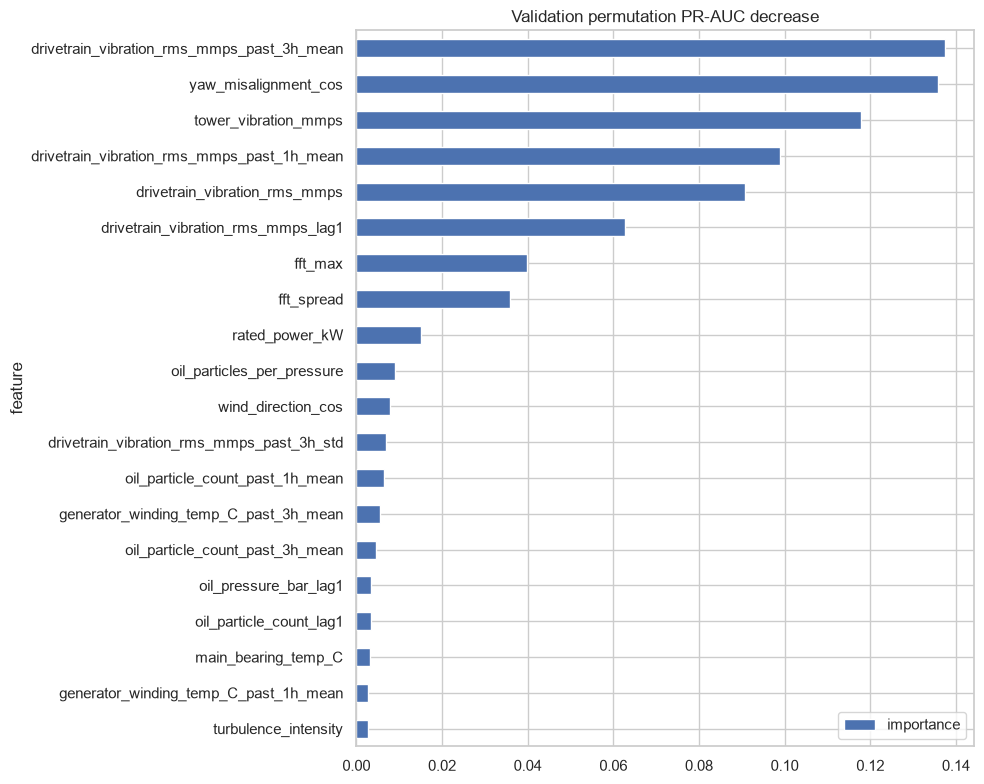

**Observation:** Leading input: drivetrain_vibration_rms_mmps_past_3h_mean. Importance reflects model association, not causation; correlated predictors can share importance.

In [90]:
importance_table=plot_feature_importances(best_model,final_valid,y_valid,selected_features)

**Observation:** Leading input: drivetrain_vibration_rms_mmps_past_3h_mean. Importance reflects model association, not causation; correlated predictors can share importance.

## Final Model Test Performance

,model,threshold,Accuracy,Recall,Precision,F1,F2,PR_AUC,ROC_AUC
0,Neural Network tuned,0.5,0.962735,0.996616,0.375398,0.54537,0.748792,0.848062,0.995508


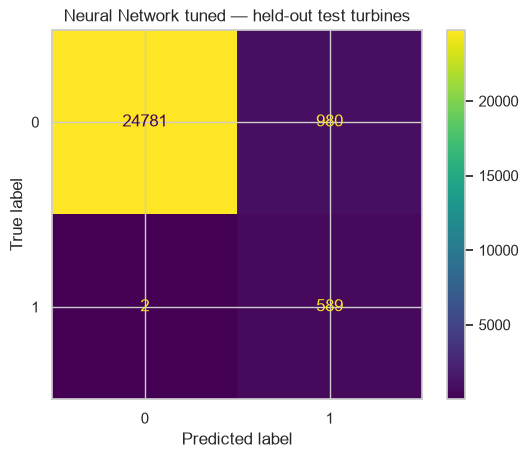

Detected fault records: 589 missed: 2 false-positive records: 980


278

In [91]:
test_probability=probabilities(best_model,final_test)
final_metrics=scores(y_test,test_probability,threshold)
display(pd.DataFrame([dict(model=selected_name,threshold=threshold,**final_metrics)]))
ConfusionMatrixDisplay.from_predictions(y_test,test_probability>=threshold); plt.title(selected_name+' — held-out test turbines'); plt.show()
tn,fp,fn,tp=confusion_matrix(y_test,test_probability>=threshold).ravel()
print('Detected fault records:',tp,'missed:',fn,'false-positive records:',fp)
(output/'final_metrics.json').write_text(json.dumps(dict(model=selected_name,threshold=threshold,**final_metrics),indent=2))


# **Business Insights and Recommendations**

## Business Insights

The leading model inputs should guide investigation of drivetrain condition, alongside the measured recall/precision tradeoff. False positives consume analyst attention; missed faults can delay intervention. Feature associations do not prove physical causes. The dataset covers 15 turbines over roughly two months, so fleet-wide performance remains uncertain. The current label describes fault detection, not advance warning.

## Recommendations

Use the classifier for analyst triage and inspection prioritization. Aggregate consecutive positive records into candidate alerts and evaluate cooldown rules before generating work orders. Review missed faults and high-importance sensors with maintenance specialists. Prospectively validate on new turbines and dates, monitor drift and alert burden, and establish an escalation policy before deployment. Previous test exposure and repeated validation reuse limit independence of the reported evaluation.

## Additional project analysis

The original detailed data-quality, feature-engineering, ablation, neural experiments, and operational analysis are preserved in [the archived completed notebook](archive/AIML_Project_1_Full_Code_Notebook_Pre_Template_Alignment.ipynb). Source notebooks 01–08 remain available. This revised submission uses their existing grouped partitions and selected engineered predictors. Its newly executed model results are stored separately in `models/template_aligned/`.

## Key Findings Recap

- All five required baseline model families were evaluated on training and validation data.
- Two tree families were selected for tuning from baseline validation results; a regularized ANN was also compared.
- The original grouped test and chronological validation partitions were retained.
- Validation selected Neural Network tuned at the fixed threshold 0.50.
- Test recall was 0.9966, precision 0.3754, and accuracy 0.9627.
- Earlier test exposure and repeated validation use limit independent confirmation.